# Clinical x IP Triangulation -- Antibody Therapeutics in Oncology

**Prepared for:** Executive / Portfolio Strategy Review (new antibody-therapeutics program scoping)
**Analyst view:** Head of Data Analytics, cross-functional patent + clinical competitive intelligence
**Sources:**
- `input/ip_final_version3.csv` (/Users/revathisekar/Documents/vibe analytics trial 2/input/ip_final_version3.csv) -- 8,901 antibody-oncology patent records
- `input/clinical_final_version1.csv` (/Users/revathisekar/Documents/vibe analytics trial 2/input/clinical_final_version1.csv) -- 19,357 antibody-oncology trial records
**Join key on BOTH sides:** the curated **`target_harmonized`** column only.

**Structure:**
- **Part A (Entries 3-9):** reproduces -- does not re-invent -- the whitespace/crowded tier logic
  already coded in `ip_landscape_final_version1.ipynb` (Entry 5D quadrants) and
  `clinical_landscape_final_version2.ipynb` (Entries 11/13/31), then cross-compares the two
  notebooks' own conclusions target-by-target, with dedicated spotlights on (i) targets the IP
  notebook calls Crowded that clinical activity hasn't caught up to, and (ii) the clinical
  notebook's Phase-1/2-only whitespace targets cross-referenced against IP crowding, and a
  solid-tumor-indication dissection of both.
- **Part B (Entries 10-17):** independent triangulation computed directly from the two raw CSVs
  (modality-adjusted crowding, filing-to-first-trial timing lag, validated/patent-thin and
  patent-crowded/unproven flags, the CAR-T IP blind spot, approximate sponsor/assignee overlap,
  and a raw-data solid-tumor-indication cut).
- **Entry 18:** consolidated executive summary.

Every table and chart below is generated live via DuckDB SQL + pandas; nothing is hand-typed.

## Entry 1: Setup & Dual Data Load (IP Patents + Clinical Trials, both on target_harmonized)

In [1]:
# Executive framing ------------------------------------------------------
# Goal: triangulate the ANTIBODY-THERAPEUTICS-IN-ONCOLOGY patent landscape
# (input/ip_final_version3.csv) against the clinical-trial landscape
# (input/clinical_final_version1.csv) to inform where WE should place our
# own antibody-therapeutics program bet. Standardized join key on BOTH
# sides: `target_harmonized` (per instruction -- no raw targets_hgnc/target_name).
con = duckdb.connect()

con.execute(f"CREATE OR REPLACE VIEW ip_raw AS SELECT * FROM read_csv_auto('{IP_CSV}')")
ip = con.sql("SELECT * FROM ip_raw").df()

con.execute(f"CREATE OR REPLACE VIEW cl_raw AS SELECT * FROM read_csv_auto('{CL_CSV}', ALL_VARCHAR=FALSE, SAMPLE_SIZE=-1)")
cl_all = con.sql("SELECT * FROM cl_raw").df()

print(f"IP patents  : {len(ip):,} rows, {ip.shape[1]} cols, {ip['target_harmonized'].nunique():,} distinct target_harmonized")
print(f"Clinical    : {len(cl_all):,} rows total, {cl_all.shape[1]} cols")
print(con.sql("SELECT in_scope, COUNT(*) AS n_rows FROM cl_raw GROUP BY 1 ORDER BY 2 DESC").df().to_string(index=False))

IP patents  : 8,901 rows, 72 cols, 1,297 distinct target_harmonized
Clinical    : 19,357 rows total, 63 cols
 in_scope  n_rows
     True   16648
    False    2684
     <NA>      25


## Entry 2: Clinical Analytic Base Table -- Scope Filter, Phase Group, Outcome Bucket, Tumor-Type Classifier

In [2]:
# Re-derives the SAME analytic base table as
# clinical_landscape_final_version2.ipynb Entries 2-3 (verbatim logic) so
# every downstream comparison in this notebook is apples-to-apples with
# that prior analysis.
df = cl_all[cl_all["in_scope"] == True].copy()  # noqa: E712 (nullable BooleanArray from DuckDB)

def phase_group(raw_phase, ctgov_phase):
    s = str(ctgov_phase) if pd.notna(ctgov_phase) and str(ctgov_phase) != "None" else str(raw_phase)
    s = s.upper()
    has1 = ("PHASE1" in s) or ("EARLY_PHASE1" in s)
    has2 = "PHASE2" in s
    has3 = "PHASE3" in s
    has4 = "PHASE4" in s
    if has4:
        return "Phase 4"
    if has3:
        return "Phase 3"
    if has2:
        return "Phase 2"
    if has1:
        return "Phase 1"
    return "Unknown"

df["phase_group"] = [phase_group(p, c) for p, c in zip(df["phase"], df["ctgov_phase"])]

OUTCOME_BUCKET = {"positive": "Success", "approved": "Success", "negative": "Failure",
                  "terminated": "Failure", "ongoing": "Ongoing/Pending", "pending": "Ongoing/Pending",
                  "unclear": "Unclear"}
df["outcome_bucket"] = df["outcome"].map(OUTCOME_BUCKET).fillna("Unclear")
df["start_year"] = pd.to_datetime(df["start_date"], errors="coerce", format="mixed").dt.year
df["target_h"] = df["target_harmonized"].replace({"": np.nan})

# Solid-tumor-type classifier -- identical taxonomy to
# clinical_landscape_final_version2.ipynb Entry 3, reused below (Entry 8/16
# of THIS notebook) so both notebooks' tumor-type labels are directly comparable,
# and reused a second time on the IP `indications` field (Entry 8) so the
# patent side can be classified into the SAME canonical tumor-type vocabulary.
TUMOR_CATEGORIES = [
    ("NSCLC", r"non[- ]?small[- ]?cell lung|nsclc"),
    ("SCLC", r"small[- ]?cell lung (carcinoma|cancer)|\bsclc\b"),
    ("Lung_Other", r"\blung\b|pulmonary"),
    ("Breast", r"\bbreast\b"),
    ("Ovarian", r"ovarian|\bovary\b"),
    ("Endometrial_Uterine", r"endometrial|\buterine\b"),
    ("Cervical", r"cervical|\bcervix\b"),
    ("Colorectal", r"colorectal|\bcolon\b|\brectal\b|\brectum\b"),
    ("Gastric_Esophageal", r"gastric|\bstomach\b|esophageal|oesophageal|gastroesophageal|\bgej\b"),
    ("Hepatocellular", r"hepatocellular|\bhcc\b"),
    ("Biliary_Cholangio", r"cholangiocarcinoma|\bbiliary\b"),
    ("Pancreatic", r"pancreatic|\bpancreas\b"),
    ("RCC", r"renal cell|\brcc\b|kidney cancer"),
    ("Bladder_Urothelial", r"\bbladder\b|urothelial"),
    ("Prostate", r"prostat"),
    ("Melanoma", r"melanoma"),
    ("HNSCC", r"head and neck|nasopharyngeal|oropharyngeal|laryngeal|hypopharyngeal|oral cavity"),
    ("Glioma_CNS", r"glioma|glioblastoma|astrocytoma|central nervous system|\bcns\b|brain (tumou?r|neoplasm)"),
    ("Mesothelioma", r"mesothelioma"),
    ("Sarcoma", r"sarcoma"),
    ("Thyroid", r"thyroid"),
    ("Skin_NonMelanoma", r"squamous cell carcinoma of the skin|cutaneous squamous|basal cell carcinoma|merkel cell"),
    ("Neuroendocrine", r"neuroendocrine|carcinoid"),
    ("GermCell_Testicular", r"testicular|germ cell"),
    ("Adrenal", r"adrenocortical|adrenal"),
    ("Salivary_Gland", r"salivary gland"),
    ("Solid_Tumor_Basket", r"solid tumou?r|advanced cancer|advanced malignant neoplasm|\bany cancer\b|metastatic cancer|metastatic solid"),
    ("Hematologic_Lymphoma", r"lymphoma"),
    ("Hematologic_Leukemia", r"leuk[ae]mia"),
    ("Hematologic_Myeloma", r"myeloma"),
    ("Hematologic_MDS_MPN", r"myelodysplastic|myeloproliferative"),
]
COMPILED_TUMOR = [(name, re.compile(pat, re.IGNORECASE)) for name, pat in TUMOR_CATEGORIES]

def classify_tumor_tags(cond_text):
    if not cond_text or pd.isna(cond_text):
        return []
    return [name for name, rx in COMPILED_TUMOR if rx.search(str(cond_text))]

df["condition_text"] = df["ctgov_conditions"].fillna(df["m_conditions"])
df["tumor_tags"] = df["condition_text"].apply(classify_tumor_tags)
con.register("trials", df)

tumor_junction = df[["nct", "target_h", "modality_code", "phase_group", "outcome_bucket",
                     "lead_sponsor_golden"]].copy()
tumor_junction["tumor_tags"] = df["tumor_tags"]
tumor_junction = tumor_junction.explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
tumor_junction = tumor_junction[tumor_junction["tumor_type"].notna()]
con.register("tumor_junction", tumor_junction)

print(f"Clinical in-scope analytic base: {len(df):,} rows ({df['nct'].nunique():,} unique NCTs)")
print(f"Tumor-tag junction rows (trial x tumor tag): {len(tumor_junction):,}")

Clinical in-scope analytic base: 16,648 rows (15,851 unique NCTs)
Tumor-tag junction rows (trial x tumor tag): 24,823


## Entry 3 [PART A]: IP Whitespace/Crowded Tiering -- Verbatim Reproduction of Prior Notebook's Entry 5D Quadrant Logic

In [3]:
# Exact SQL/thresholds as coded in ip_landscape_final_version1.ipynb Entry 5D
# (total_patents >= 30 = "high volume"; pct_recent >= 30% filed since 2023 =
# "high momentum"), universe = targets with >= 3 patents. The 4 original
# quadrants are collapsed to 3 tiers for direct comparison with the
# clinical side: Crowded = Hot/Crowded + Mature/Legacy (high volume);
# Whitespace (High Risk) = Emerging Whitespace (low volume, accelerating);
# Medium = Quiet/Underexplored (low volume, low momentum).
sql_ip_quadrant = f'''
    WITH base AS (
      SELECT target_harmonized AS t, filing_year
      FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL
    ),
    agg AS (
      SELECT t AS target_harmonized, COUNT(*) AS total_patents,
             SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END) AS recent_3y,
             ROUND(100.0*SUM(CASE WHEN filing_year >= 2023 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_recent
      FROM base GROUP BY 1 HAVING COUNT(*) >= 3
    )
    SELECT target_harmonized, total_patents, recent_3y, pct_recent,
      CASE
        WHEN total_patents >= 30 AND pct_recent >= 30 THEN 'Hot/Crowded (high volume, high momentum)'
        WHEN total_patents >= 30 AND pct_recent < 30 THEN 'Mature/Legacy (high volume, cooling)'
        WHEN total_patents < 30 AND pct_recent >= 30 THEN 'Emerging Whitespace (low volume, accelerating)'
        ELSE 'Quiet/Underexplored (low volume, low momentum)'
      END AS whitespace_quadrant
    FROM agg ORDER BY total_patents DESC;
'''
IP_QUADRANT = con.sql(sql_ip_quadrant).df()

def ip_tier(q):
    if q in ("Hot/Crowded (high volume, high momentum)", "Mature/Legacy (high volume, cooling)"):
        return "Crowded"
    if q == "Emerging Whitespace (low volume, accelerating)":
        return "Whitespace (High Risk)"
    return "Medium"

IP_QUADRANT["ip_tier"] = IP_QUADRANT["whitespace_quadrant"].apply(ip_tier)
display(IP_QUADRANT, name="entry03_ip_tier_full")
print(f"IP tiering universe (target_harmonized, >=3 patents): {len(IP_QUADRANT)}")
display(IP_QUADRANT["ip_tier"].value_counts().rename_axis("ip_tier").reset_index(name="n_targets"),
        name="entry03_ip_tier_counts")

IP tiering universe (target_harmonized, >=3 patents): 338


,target_harmonized,total_patents,recent_3y,pct_recent,whitespace_quadrant,ip_tier
0,PD-1,278,72.0,25.9,"Mature/Legacy (high volume, cooling)",Crowded
1,PD-L1,178,43.0,24.2,"Mature/Legacy (high volume, cooling)",Crowded
2,HER2,156,71.0,45.5,"Hot/Crowded (high volume, high momentum)",Crowded
3,EGFR,128,30.0,23.4,"Mature/Legacy (high volume, cooling)",Crowded
4,CD3,81,33.0,40.7,"Hot/Crowded (high volume, high momentum)",Crowded
5,CTLA-4,73,32.0,43.8,"Hot/Crowded (high volume, high momentum)",Crowded
6,B7-H3,66,36.0,54.5,"Hot/Crowded (high volume, high momentum)",Crowded
7,CD47,61,7.0,11.5,"Mature/Legacy (high volume, cooling)",Crowded
8,TIGIT,49,11.0,22.4,"Mature/Legacy (high volume, cooling)",Crowded
9,TROP-2,48,29.0,60.4,"Hot/Crowded (high volume, high momentum)",Crowded


,ip_tier,n_targets
0,Medium,155
1,Whitespace (High Risk),153
2,Crowded,30


## Entry 4 [PART A]: Clinical Whitespace/Crowded Tiering -- Verbatim Reproduction of Prior Notebook's Entry 11/13/31 Logic

In [4]:
# Entry 11: TARGET_SCORECARD, targets with >=5 trials.
TARGET_SCORECARD = con.sql('''
    SELECT target_h AS target_harmonized, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials WHERE target_h IS NOT NULL GROUP BY 1 HAVING COUNT(*) >= 5 ORDER BY n_trials DESC
''').df()

# Entry 13: crowding matrix -- "Crowded" = top-20 targets by trial volume.
CROWDED_TOP20 = TARGET_SCORECARD.sort_values("n_trials", ascending=False).head(20)["target_harmonized"].tolist()

# Entry 31: Phase-1/2-ONLY whitespace model -- zero recorded failures,
# entire footprint Phase 1/2/Unknown (no Phase 3/4 ever seen), active
# since 2019. No minimum trial-count threshold (as originally coded).
target_stats = con.sql('''
    SELECT target_h AS target_harmonized, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           MAX(start_year) AS latest_start_year, MIN(start_year) AS earliest_start_year,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN phase_group IN ('Phase 1','Phase 2') THEN 1 ELSE 0 END) AS n_ph12,
           SUM(CASE WHEN phase_group IN ('Phase 3','Phase 4') THEN 1 ELSE 0 END) AS n_late_stage
    FROM trials WHERE target_h IS NOT NULL GROUP BY 1
''').df()
WHITESPACE_OVERALL = target_stats[(target_stats["n_late_stage"] == 0) & (target_stats["n_ph12"] > 0) &
                                   (target_stats["n_failure"] == 0) & (target_stats["latest_start_year"] >= 2019)]
WHITESPACE_TARGETS = WHITESPACE_OVERALL["target_harmonized"].tolist()

def cl_tier(t):
    if t in CROWDED_TOP20:
        return "Crowded"
    if t in WHITESPACE_TARGETS:
        return "Whitespace (High Risk)"
    return "Medium"

cl_universe = sorted(set(TARGET_SCORECARD["target_harmonized"]) | set(WHITESPACE_TARGETS))
CL_TIER = pd.DataFrame({"target_harmonized": cl_universe})
CL_TIER["cl_tier"] = CL_TIER["target_harmonized"].apply(cl_tier)
CL_TIER = CL_TIER.merge(TARGET_SCORECARD, on="target_harmonized", how="left")
CL_TIER = CL_TIER.merge(target_stats[["target_harmonized", "latest_start_year", "n_ph12", "n_late_stage"]],
                        on="target_harmonized", how="left")

display(CL_TIER, name="entry04_clinical_tier_full")
print(f"Clinical tiering universe: {len(CL_TIER)} (TARGET_SCORECARD >=5 trials: {len(TARGET_SCORECARD)}; "
      f"WHITESPACE_OVERALL, no min-trial threshold: {len(WHITESPACE_TARGETS)})")
display(CL_TIER["cl_tier"].value_counts().rename_axis("cl_tier").reset_index(name="n_targets"),
        name="entry04_clinical_tier_counts")

Clinical tiering universe: 907 (TARGET_SCORECARD >=5 trials: 243; WHITESPACE_OVERALL, no min-trial threshold: 686)


,target_harmonized,cl_tier,n_trials,n_sponsors,n_success,n_failure,latest_start_year,n_ph12,n_late_stage
0,5T4-Duocarmycin,Whitespace (High Risk),-,-,-,-,2020.0,1.0,0.0
1,5T4-Exatecan,Whitespace (High Risk),-,-,-,-,2024.0,1.0,0.0
2,5T4-MMAE,Whitespace (High Risk),-,-,-,-,2024.0,1.0,0.0
3,5T4-MMAF,Whitespace (High Risk),-,-,-,-,2022.0,1.0,0.0
4,5T4|CD137,Whitespace (High Risk),-,-,-,-,2025.0,2.0,0.0
5,5T4|CD19,Whitespace (High Risk),-,-,-,-,2021.0,2.0,0.0
6,ADAM9-Exatecan,Whitespace (High Risk),-,-,-,-,2025.0,1.0,0.0
7,ALK|AXL|EGFR|PD-1-MMAE,Whitespace (High Risk),-,-,-,-,2021.0,1.0,0.0
8,ALK|CD20|CD3,Whitespace (High Risk),-,-,-,-,2025.0,1.0,0.0
9,ALK|CD25,Whitespace (High Risk),-,-,-,-,2020.0,1.0,0.0


,cl_tier,n_targets
0,Whitespace (High Risk),686
1,Medium,201
2,Crowded,20


## Entry 5 [PART A]: Cross-Notebook Tier Comparison -- Merge on target_harmonized

Targets present in BOTH IP and Clinical tier universes: 128


,target_harmonized,total_patents,pct_recent,ip_tier,n_trials,n_success,n_failure,cl_tier,_merge,match_status
0,5T4,11.0,45.5,Whitespace (High Risk),-,-,-,-,left_only,IP-only (no clinical tier)
1,5T4-Duocarmycin,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
2,5T4-Exatecan,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
3,5T4-MMAE,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
4,5T4-MMAF,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
5,5T4|CD137,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
6,5T4|CD19,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)
7,5T4|CD3,6.0,16.7,Medium,-,-,-,-,left_only,IP-only (no clinical tier)
8,ADAM17,3.0,0.0,Medium,-,-,-,-,left_only,IP-only (no clinical tier)
9,ADAM9-Exatecan,-,-,-,-,-,-,Whitespace (High Risk),right_only,Clinical-only (no IP tier)


,status,n_targets
0,MISMATCH,66
1,MATCH,62


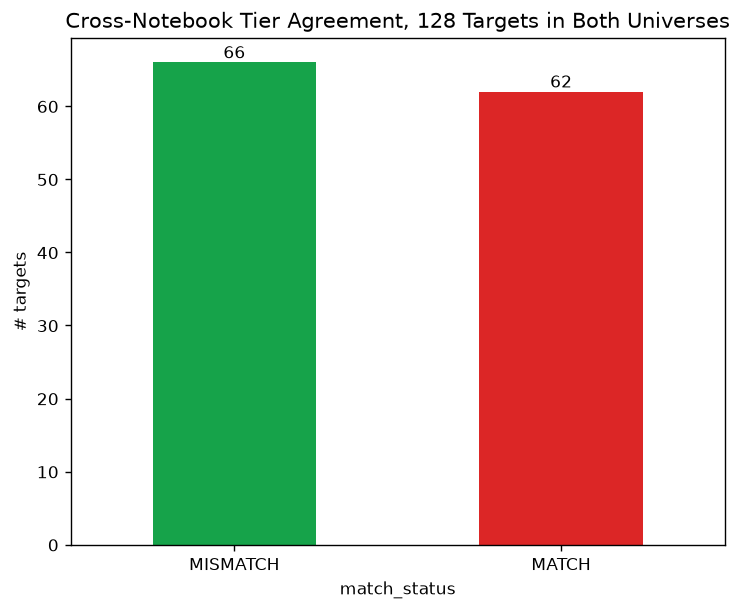

In [5]:
ip_small = IP_QUADRANT.rename(columns={"ip_tier": "ip_tier"})[["target_harmonized", "total_patents", "pct_recent", "ip_tier"]]
cl_small = CL_TIER.rename(columns={"cl_tier": "cl_tier"})[["target_harmonized", "n_trials", "n_success", "n_failure", "cl_tier"]]
MERGED_TIERS = ip_small.merge(cl_small, on="target_harmonized", how="outer", indicator=True)

def match_status(row):
    if row["_merge"] == "left_only":
        return "IP-only (no clinical tier)"
    if row["_merge"] == "right_only":
        return "Clinical-only (no IP tier)"
    if row["ip_tier"] == row["cl_tier"]:
        return f"MATCH ({row['ip_tier']})"
    return f"MISMATCH (IP={row['ip_tier']} / Clinical={row['cl_tier']})"

MERGED_TIERS["match_status"] = MERGED_TIERS.apply(match_status, axis=1)
display(MERGED_TIERS, name="entry05_merged_tiers_full")

both = MERGED_TIERS[MERGED_TIERS["_merge"] == "both"]
print(f"Targets present in BOTH IP and Clinical tier universes: {len(both)}")
summary = both["match_status"].apply(lambda s: "MATCH" if s.startswith("MATCH") else "MISMATCH").value_counts()
display(summary.rename_axis("status").reset_index(name="n_targets"), name="entry05_match_summary")

fig, ax = plt.subplots(figsize=(6, 5))
summary.plot(kind="bar", ax=ax, color=["#16a34a", "#dc2626"])
ax.set_title(f"Cross-Notebook Tier Agreement, {len(both)} Targets in Both Universes")
ax.set_ylabel("# targets"); ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(summary.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()

## Entry 6 [PART A]: Crowded-in-Both / Whitespace-in-Both / Medium-in-Both -- Full Target Lists

In [6]:
both = MERGED_TIERS[MERGED_TIERS["_merge"] == "both"]

crowded_both = both[(both["ip_tier"] == "Crowded") & (both["cl_tier"] == "Crowded")].sort_values("total_patents", ascending=False)
ws_both = both[(both["ip_tier"] == "Whitespace (High Risk)") & (both["cl_tier"] == "Whitespace (High Risk)")]
medium_both = both[(both["ip_tier"] == "Medium") & (both["cl_tier"] == "Medium")]

print(f"CROWDED in both ({len(crowded_both)}): most-validated, most-contested targets -- de-risked biology, but a crowded IP field.")
display(crowded_both[["target_harmonized", "total_patents", "n_trials", "n_success", "n_failure"]], name="entry06_crowded_in_both")

print(f"\nWHITESPACE (High Risk) in both ({len(ws_both)}): patent-thin AND clinically-thin -- highest upside, highest uncertainty.")
display(ws_both[["target_harmonized", "total_patents", "pct_recent", "n_trials"]], name="entry06_whitespace_in_both")

print(f"\nMEDIUM in both ({len(medium_both)}): moderate activity on both sides -- neither clearly open nor clearly closed.")
display(medium_both[["target_harmonized", "total_patents", "n_trials", "n_success", "n_failure"]], name="entry06_medium_in_both")

mismatches = both[both["ip_tier"] != both["cl_tier"]].sort_values(["ip_tier", "cl_tier"])
print(f"\nALL MISMATCHES ({len(mismatches)}): different tier assigned by each prior notebook.")
display(mismatches[["target_harmonized", "ip_tier", "cl_tier", "total_patents", "pct_recent", "n_trials", "n_success", "n_failure"]],
        name="entry06_all_mismatches")

CROWDED in both (9): most-validated, most-contested targets -- de-risked biology, but a crowded IP field.

WHITESPACE (High Risk) in both (25): patent-thin AND clinically-thin -- highest upside, highest uncertainty.

MEDIUM in both (28): moderate activity on both sides -- neither clearly open nor clearly closed.

ALL MISMATCHES (66): different tier assigned by each prior notebook.


,target_harmonized,total_patents,n_trials,n_success,n_failure
740,PD-1,278.0,2908.0,350.0,365.0
910,PD-L1,178.0,791.0,81.0,138.0
554,HER2,156.0,1171.0,69.0,156.0
434,EGFR,128.0,738.0,16.0,202.0
384,CTLA-4,73.0,142.0,28.0,30.0
1015,TROP-2,48.0,84.0,6.0,10.0
174,CD20,44.0,788.0,33.0,156.0
1051,VEGF,36.0,863.0,224.0,125.0
146,CD19,31.0,432.0,11.0,37.0


,target_harmonized,total_patents,pct_recent,n_trials
26,AR,9.0,44.4,5.0
43,B7-H3|CD28,5.0,80.0,-
65,BCL-2,12.0,33.3,-
225,CD26,8.0,37.5,-
250,CD38|CD3,7.0,42.9,-
254,CD39,10.0,30.0,-
270,CD3|TCR,24.0,33.3,-
288,CD47|PD-L1,10.0,40.0,-
329,CDH6,8.0,37.5,-
354,CLDN1,3.0,66.7,-


,target_harmonized,total_patents,n_trials,n_success,n_failure
116,CD123,9.0,25.0,0.0,5.0
221,CD25,29.0,24.0,1.0,5.0
232,CD30-MMAE,6.0,6.0,2.0,0.0
239,CD33,20.0,83.0,6.0,17.0
333,CEA,15.0,50.0,2.0,7.0
372,CLDN6,11.0,8.0,1.0,1.0
378,CLL-1,5.0,10.0,0.0,1.0
453,EGFR|HER3,7.0,11.0,3.0,1.0
488,EpCAM,15.0,14.0,0.0,1.0
526,GD2,19.0,82.0,5.0,11.0


,target_harmonized,ip_tier,cl_tier,total_patents,pct_recent,n_trials,n_success,n_failure
36,B7-H3,Crowded,Medium,66.0,54.5,61.0,2.0,5.0
86,BCMA|CD3,Crowded,Medium,33.0,33.3,57.0,3.0,7.0
130,CD137,Crowded,Medium,44.0,20.5,14.0,0.0,5.0
192,CD20|CD3,Crowded,Medium,47.0,36.2,65.0,8.0,5.0
230,CD3,Crowded,Medium,81.0,40.7,28.0,0.0,5.0
272,CD40,Crowded,Medium,33.0,12.1,32.0,1.0,4.0
278,CD47,Crowded,Medium,61.0,11.5,16.0,0.0,7.0
355,CLDN18.2,Crowded,Medium,45.0,28.9,35.0,5.0,4.0
424,DLL3,Crowded,Medium,30.0,76.7,22.0,0.0,6.0
460,EGFR|MET,Crowded,Medium,45.0,73.3,54.0,8.0,7.0


## Entry 7 [PART A -- SPOTLIGHT]: 'IP Crowded, Clinical Hasn't Caught Up' -- Heavily Patented Targets With Little/No Clinical Validation Yet

21 of 30 IP-Crowded targets have NOT been matched by clinical activity (no trials at all, or trials exist but below the clinical Crowded bar).


,target_harmonized,total_patents,pct_recent,n_trials,n_success,n_failure,clinical_status
230,CD3,81.0,40.7,28.0,0.0,5.0,Clinical tier = Medium
36,B7-H3,66.0,54.5,61.0,2.0,5.0,Clinical tier = Medium
278,CD47,61.0,11.5,16.0,0.0,7.0,Clinical tier = Medium
1004,TIGIT,49.0,22.4,12.0,0.0,7.0,Clinical tier = Medium
192,CD20|CD3,47.0,36.2,65.0,8.0,5.0,Clinical tier = Medium
686,MET,45.0,15.6,53.0,5.0,12.0,Clinical tier = Medium
999,TCR,45.0,31.1,20.0,0.0,7.0,Clinical tier = Medium
355,CLDN18.2,45.0,28.9,35.0,5.0,4.0,Clinical tier = Medium
460,EGFR|MET,45.0,73.3,54.0,8.0,7.0,Clinical tier = Medium
130,CD137,44.0,20.5,14.0,0.0,5.0,Clinical tier = Medium


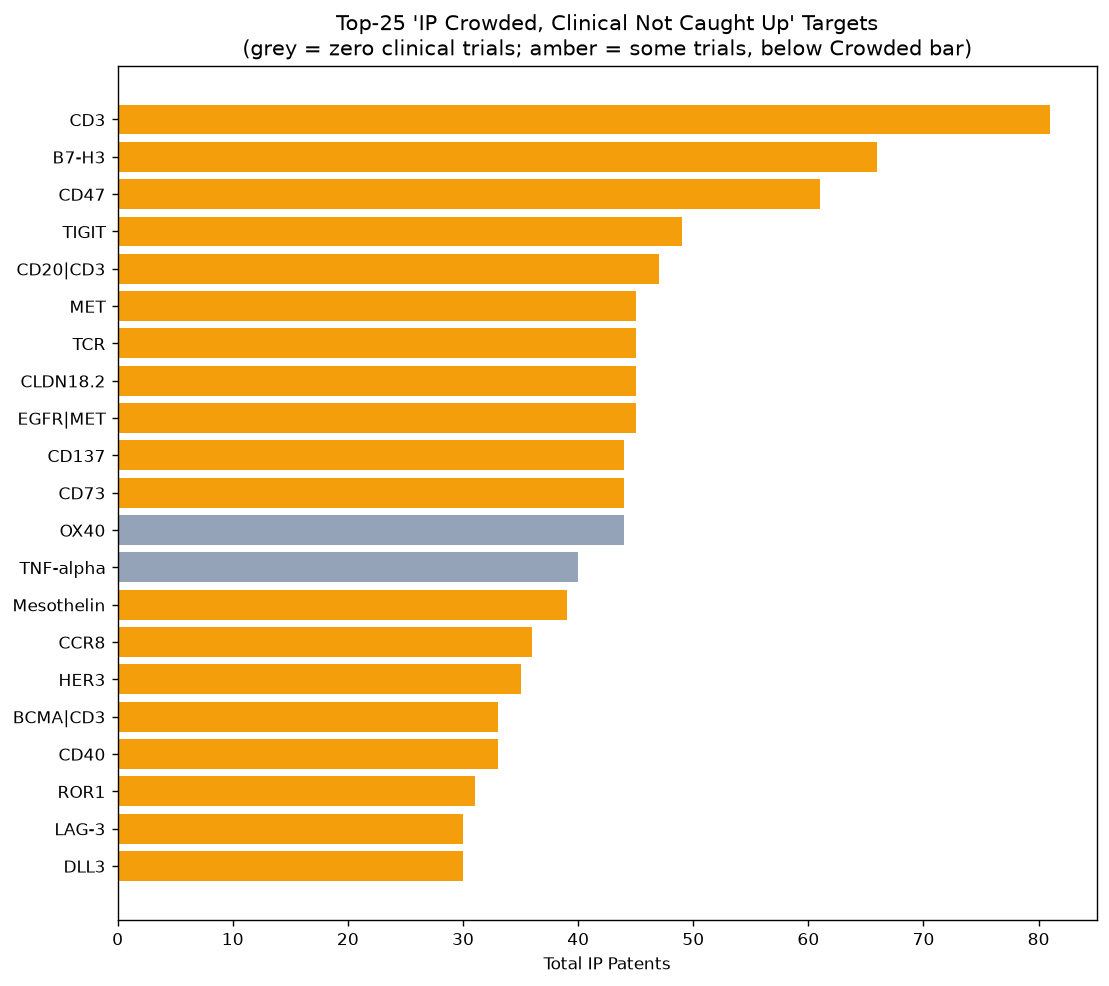

In [7]:
# Every target the IP notebook calls Crowded (>=30 patents) where the
# clinical notebook does NOT also call it Crowded -- i.e. patent filers
# are racing ahead of clinical proof. Includes targets absent entirely
# from the clinical >=5-trial/whitespace universe (IP-only).
ip_crowded_all = MERGED_TIERS[MERGED_TIERS["ip_tier"] == "Crowded"].copy()
ip_crowded_not_caught = ip_crowded_all[ip_crowded_all["cl_tier"] != "Crowded"].copy()
ip_crowded_not_caught["clinical_status"] = np.where(
    ip_crowded_not_caught["_merge"] == "left_only", "No clinical trial data at all (target absent from clinical universe)",
    ip_crowded_not_caught["cl_tier"].apply(lambda t: f"Clinical tier = {t}" if pd.notna(t) else "n/a"))
ip_crowded_not_caught = ip_crowded_not_caught.sort_values("total_patents", ascending=False)

cols = ["target_harmonized", "total_patents", "pct_recent", "n_trials", "n_success", "n_failure", "clinical_status"]
display(ip_crowded_not_caught[cols], name="entry07_ip_crowded_clinical_not_caught")
print(f"{len(ip_crowded_not_caught)} of {len(ip_crowded_all)} IP-Crowded targets have NOT been matched by clinical "
      f"activity (no trials at all, or trials exist but below the clinical Crowded bar).")

fig, ax = plt.subplots(figsize=(9, 8))
top25 = ip_crowded_not_caught.head(25).iloc[::-1]
colors = ["#94a3b8" if s.startswith("No clinical") else "#f59e0b" for s in top25["clinical_status"]]
ax.barh(top25["target_harmonized"], top25["total_patents"], color=colors)
ax.set_xlabel("Total IP Patents"); ax.set_title("Top-25 'IP Crowded, Clinical Not Caught Up' Targets\n(grey = zero clinical trials; amber = some trials, below Crowded bar)")
plt.tight_layout()

## Entry 8 [PART A -- SPOTLIGHT]: Clinical Phase 1/2 Whitespace Targets Cross-Referenced Against IP Tier

686 clinical Phase-1/2 whitespace targets, split by IP-side reality:


,target_harmonized,n_trials,n_success,latest_start_year,n_ph12,total_patents,pct_recent,ip_status
190,CD70,34.0,0.0,2026.0,32.0,13.0,15.4,Medium
286,EGFR|HER2,20.0,2.0,2026.0,19.0,5.0,20.0,Medium
342,GPRC5D,14.0,1.0,2024.0,13.0,8.0,25.0,Medium
381,HER2|TROP-2,13.0,1.0,2026.0,9.0,3.0,66.7,Whitespace (High Risk)
136,CD20|CD3|BTK,9.0,0.0,2025.0,9.0,-,-,No IP patent data at all (target absent from IP universe)
78,BTK,8.0,1.0,2025.0,5.0,4.0,25.0,Medium
71,BCMA|CD3|GPRC5D,8.0,0.0,2026.0,8.0,-,-,No IP patent data at all (target absent from IP universe)
196,CD73,7.0,0.0,2026.0,7.0,44.0,20.5,Crowded
570,PD-1|VEGF|VEGFR2,6.0,0.0,2026.0,6.0,-,-,No IP patent data at all (target absent from IP universe)
471,PD-1|CD19,6.0,2.0,2025.0,6.0,-,-,No IP patent data at all (target absent from IP universe)


,ip_status,n_targets
0,No IP patent data at all (target absent from IP universe),643
1,Whitespace (High Risk),25
2,Medium,15
3,Crowded,3


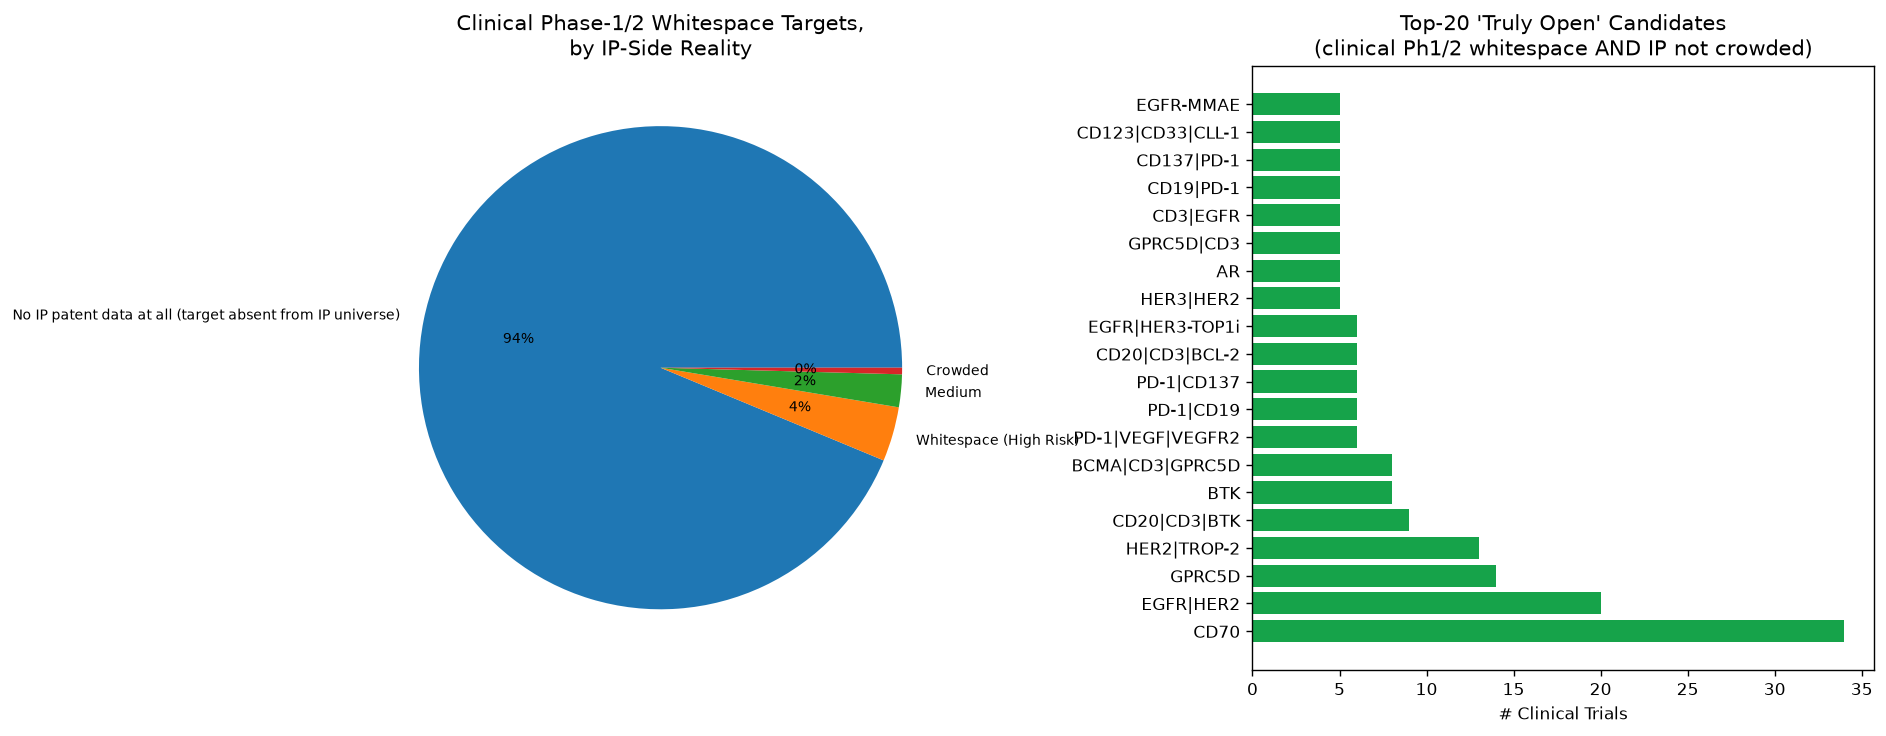

In [8]:
# The clinical notebook's Phase-1/2-only whitespace list (zero failures,
# active since 2019) is the most interesting set for program design --
# cross-reference every one of those targets against its IP tier to see
# which are TRULY wide open (also IP-whitespace/medium) vs which are a
# clinical green light sitting on top of a crowded patent minefield.
ws_clinical = MERGED_TIERS[MERGED_TIERS["cl_tier"] == "Whitespace (High Risk)"].copy()
ws_clinical["ip_status"] = np.where(ws_clinical["_merge"] == "right_only",
                                    "No IP patent data at all (target absent from IP universe)",
                                    ws_clinical["ip_tier"])
ws_clinical = ws_clinical.merge(
    CL_TIER[["target_harmonized", "latest_start_year", "n_ph12"]], on="target_harmonized", how="left", suffixes=("", "_dup")
)
ws_clinical = ws_clinical.sort_values("n_trials", ascending=False)

cols = ["target_harmonized", "n_trials", "n_success", "latest_start_year", "n_ph12", "total_patents", "pct_recent", "ip_status"]
display(ws_clinical[cols], name="entry08_clinical_whitespace_x_ip_tier")

breakdown = ws_clinical["ip_status"].value_counts()
print(f"{len(ws_clinical)} clinical Phase-1/2 whitespace targets, split by IP-side reality:")
display(breakdown.rename_axis("ip_status").reset_index(name="n_targets"), name="entry08_ip_status_breakdown")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
breakdown.plot(kind="pie", ax=axes[0], autopct="%1.0f%%", textprops={"fontsize": 8})
axes[0].set_ylabel(""); axes[0].set_title("Clinical Phase-1/2 Whitespace Targets,\nby IP-Side Reality")

truly_open = ws_clinical[ws_clinical["ip_status"].isin(["No IP patent data at all (target absent from IP universe)",
                                                         "Whitespace (High Risk)", "Medium"])].nlargest(20, "n_trials")
axes[1].barh(truly_open["target_harmonized"], truly_open["n_trials"], color="#16a34a")
axes[1].set_xlabel("# Clinical Trials"); axes[1].set_title("Top-20 'Truly Open' Candidates\n(clinical Ph1/2 whitespace AND IP not crowded)")
plt.tight_layout()

## Entry 9 [PART A]: Solid-Tumor-Indication Dissection of Both Notebooks' Tiers

55 spotlighted targets x 26 solid-tumor indications, 862 non-empty combos.


,target_harmonized,tumor_type,n_patents,n_trials,ip_tier,cl_tier
11,AR,Prostate,5,2,Whitespace (High Risk),Whitespace (High Risk)
1,AR,Breast,2,0,Whitespace (High Risk),Whitespace (High Risk)
0,AR,Bladder_Urothelial,1,0,Whitespace (High Risk),Whitespace (High Risk)
2,AR,Cervical,1,0,Whitespace (High Risk),Whitespace (High Risk)
3,AR,Colorectal,1,0,Whitespace (High Risk),Whitespace (High Risk)
4,AR,Glioma_CNS,1,1,Whitespace (High Risk),Whitespace (High Risk)
5,AR,HNSCC,1,0,Whitespace (High Risk),Whitespace (High Risk)
6,AR,Hepatocellular,1,0,Whitespace (High Risk),Whitespace (High Risk)
7,AR,Lung_Other,1,0,Whitespace (High Risk),Whitespace (High Risk)
8,AR,Melanoma,1,0,Whitespace (High Risk),Whitespace (High Risk)


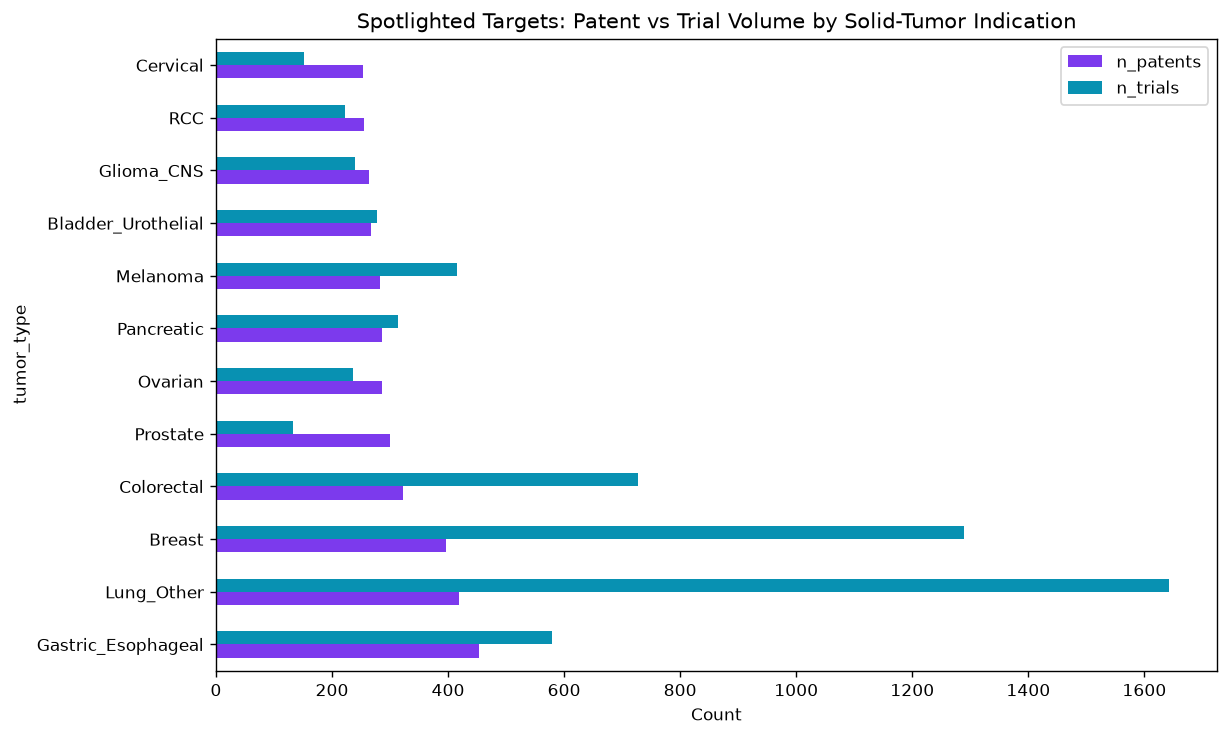

In [9]:
# IP side: classify the free-text `indications` field into the SAME
# canonical tumor-type taxonomy used by the clinical notebook (Entry 2 of
# THIS notebook), so both sides are directly comparable indication-by-indication.
HEME_KEYWORDS = ["leukemia", "lymphoma", "myeloma", "hematologic", "hematological", "blood cancer",
                 "AML", "ALL", "CLL", "CML", "MDS", "multiple myeloma", "non-hodgkin", "hodgkin"]

ip_ind = con.sql(f'''
    SELECT target_harmonized AS target_h, TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS raw_indication
    FROM read_csv_auto('{IP_CSV}')
    WHERE target_harmonized IS NOT NULL AND indications IS NOT NULL
      AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
''').df()
ip_ind["tumor_tags"] = ip_ind["raw_indication"].apply(classify_tumor_tags)
ip_junction = ip_ind.explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
ip_junction = ip_junction[ip_junction["tumor_type"].notna() & ~ip_junction["tumor_type"].str.startswith("Hematologic")
                          & (ip_junction["tumor_type"] != "Solid_Tumor_Basket")]

ip_by_target_tumor = ip_junction.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_patents")
cl_by_target_tumor = tumor_junction[~tumor_junction["tumor_type"].str.startswith("Hematologic") &
                                    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")]
cl_by_target_tumor = cl_by_target_tumor.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_trials")

# Focus on the three headline sets from Entries 6-8: Crowded-in-both,
# Whitespace-in-both, and IP-Crowded-Clinical-Not-Caught.
focus_targets = sorted(set(crowded_both["target_harmonized"]) | set(ws_both["target_harmonized"]) |
                        set(ip_crowded_not_caught["target_harmonized"].head(25)))

ip_focus = ip_by_target_tumor[ip_by_target_tumor["target_h"].isin(focus_targets)]
cl_focus = cl_by_target_tumor[cl_by_target_tumor["target_h"].isin(focus_targets)]
indication_dissect = ip_focus.merge(cl_focus, on=["target_h", "tumor_type"], how="outer").fillna(0)
indication_dissect = indication_dissect.rename(columns={"target_h": "target_harmonized"})
indication_dissect["n_patents"] = indication_dissect["n_patents"].astype(int)
indication_dissect["n_trials"] = indication_dissect["n_trials"].astype(int)
indication_dissect = indication_dissect.merge(MERGED_TIERS[["target_harmonized", "ip_tier", "cl_tier"]].drop_duplicates("target_harmonized"),
                                               on="target_harmonized", how="left")
indication_dissect = indication_dissect.sort_values(["target_harmonized", "n_patents"], ascending=[True, False])
display(indication_dissect, name="entry09_solid_tumor_indication_dissection")
print(f"{indication_dissect['target_harmonized'].nunique()} spotlighted targets x "
      f"{indication_dissect['tumor_type'].nunique()} solid-tumor indications, {len(indication_dissect)} non-empty combos.")

top_indications = indication_dissect.groupby("tumor_type")[["n_patents", "n_trials"]].sum().sort_values("n_patents", ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 6))
top_indications.plot(kind="barh", ax=ax, color=["#7c3aed", "#0891b2"])
ax.set_title("Spotlighted Targets: Patent vs Trial Volume by Solid-Tumor Indication"); ax.set_xlabel("Count")
plt.tight_layout()

## Entry 10 [PART B]: Independent Raw-Data Triangulation -- Direct Patent-Count vs Trial-Count Quadrant

,target_harmonized,n_patents,n_trials,raw_quadrant
1768,PD-1,278,2908,"Crowded Both (above-median volume, both sides)"
2038,PD-L1,178,791,"Crowded Both (above-median volume, both sides)"
1254,HER2,156,1171,"Crowded Both (above-median volume, both sides)"
983,EGFR,128,738,"Crowded Both (above-median volume, both sides)"
488,CD3,81,28,"Crowded Both (above-median volume, both sides)"
833,CTLA-4,73,142,"Crowded Both (above-median volume, both sides)"
94,B7-H3,66,61,"Crowded Both (above-median volume, both sides)"
628,CD47,61,16,"Crowded Both (above-median volume, both sides)"
2321,TIGIT,49,12,"Crowded Both (above-median volume, both sides)"
2372,TROP-2,48,84,"Crowded Both (above-median volume, both sides)"


,raw_quadrant,n_targets
0,"Clinical-only (trialed, zero patents)",1292
1,"IP-only (patented, zero trials)",1017
2,"Crowded Both (above-median volume, both sides)",280


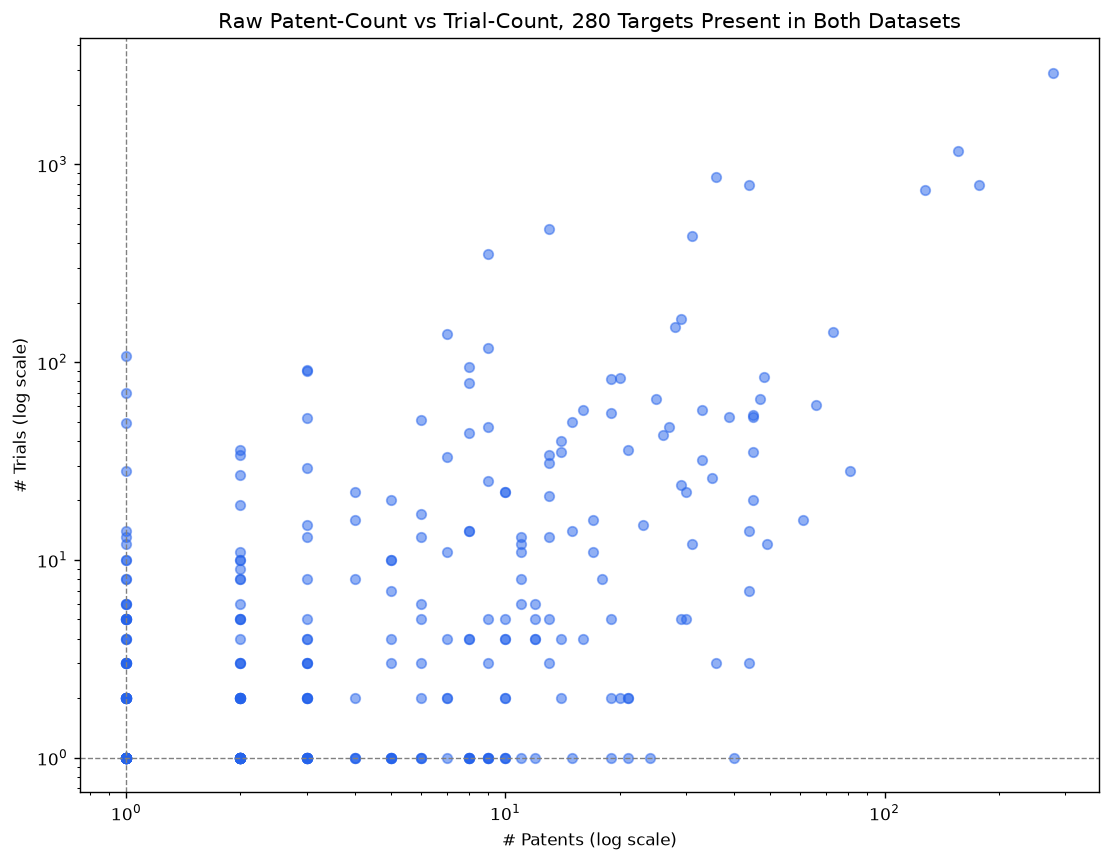

In [10]:
# Computed FRESH from the two raw CSVs (not derived from either prior
# notebook) as a sanity check against Part A: simple patent-volume vs
# trial-volume crossing, no phase/momentum logic at all.
ip_counts = con.sql(f'''
    SELECT target_harmonized, COUNT(*) AS n_patents
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1
''').df()
cl_counts = df.groupby("target_h").size().reset_index(name="n_trials").rename(columns={"target_h": "target_harmonized"})

RAW_TRIANGULATION = ip_counts.merge(cl_counts, on="target_harmonized", how="outer").fillna(0)
RAW_TRIANGULATION["n_patents"] = RAW_TRIANGULATION["n_patents"].astype(int)
RAW_TRIANGULATION["n_trials"] = RAW_TRIANGULATION["n_trials"].astype(int)

ip_med = RAW_TRIANGULATION.loc[RAW_TRIANGULATION["n_patents"] > 0, "n_patents"].median()
cl_med = RAW_TRIANGULATION.loc[RAW_TRIANGULATION["n_trials"] > 0, "n_trials"].median()

def raw_quadrant(row):
    has_ip, has_cl = row["n_patents"] > 0, row["n_trials"] > 0
    if not has_ip and not has_cl:
        return "Neither (not in either dataset)"
    if has_ip and not has_cl:
        return "IP-only (patented, zero trials)"
    if has_cl and not has_ip:
        return "Clinical-only (trialed, zero patents)"
    if row["n_patents"] >= ip_med and row["n_trials"] >= cl_med:
        return "Crowded Both (above-median volume, both sides)"
    if row["n_patents"] < ip_med and row["n_trials"] < cl_med:
        return "Whitespace Both (below-median volume, both sides)"
    return "Split (crowded one side, thin the other)"

RAW_TRIANGULATION["raw_quadrant"] = RAW_TRIANGULATION.apply(raw_quadrant, axis=1)
display(RAW_TRIANGULATION.sort_values("n_patents", ascending=False), name="entry10_raw_triangulation_full")
display(RAW_TRIANGULATION["raw_quadrant"].value_counts().rename_axis("raw_quadrant").reset_index(name="n_targets"),
        name="entry10_raw_quadrant_counts")

fig, ax = plt.subplots(figsize=(9, 7))
both_only = RAW_TRIANGULATION[(RAW_TRIANGULATION["n_patents"] > 0) & (RAW_TRIANGULATION["n_trials"] > 0)]
ax.scatter(both_only["n_patents"], both_only["n_trials"], alpha=0.5, s=30, c="#2563eb")
ax.axvline(ip_med, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(cl_med, color="gray", linestyle="--", linewidth=0.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("# Patents (log scale)"); ax.set_ylabel("# Trials (log scale)")
ax.set_title(f"Raw Patent-Count vs Trial-Count, {len(both_only)} Targets Present in Both Datasets")
plt.tight_layout()

## Entry 11 [PART B]: Modality-Adjusted Crowding -- Same Target, Different Modality Buckets

29 targets have IP activity in >=2 distinct modality buckets -- a target 'crowded' at the antigen level may still have an open modality-specific niche.


,target_harmonized,modality_code,n_patents,n_trials
3,5T4,MAB,7,0
11,5T4|CD3,BISPECIFIC,6,2
29,ALK,MAB,5,4
56,ANG2,MAB,3,2
58,ANG2|VEGF,BISPECIFIC,12,0
69,AR,MAB,4,4
70,AR,PROTAC,4,1
84,AXL,MAB,17,1
85,AXL-MMAE,ADC,2,3
110,B7-H3,MAB,35,15


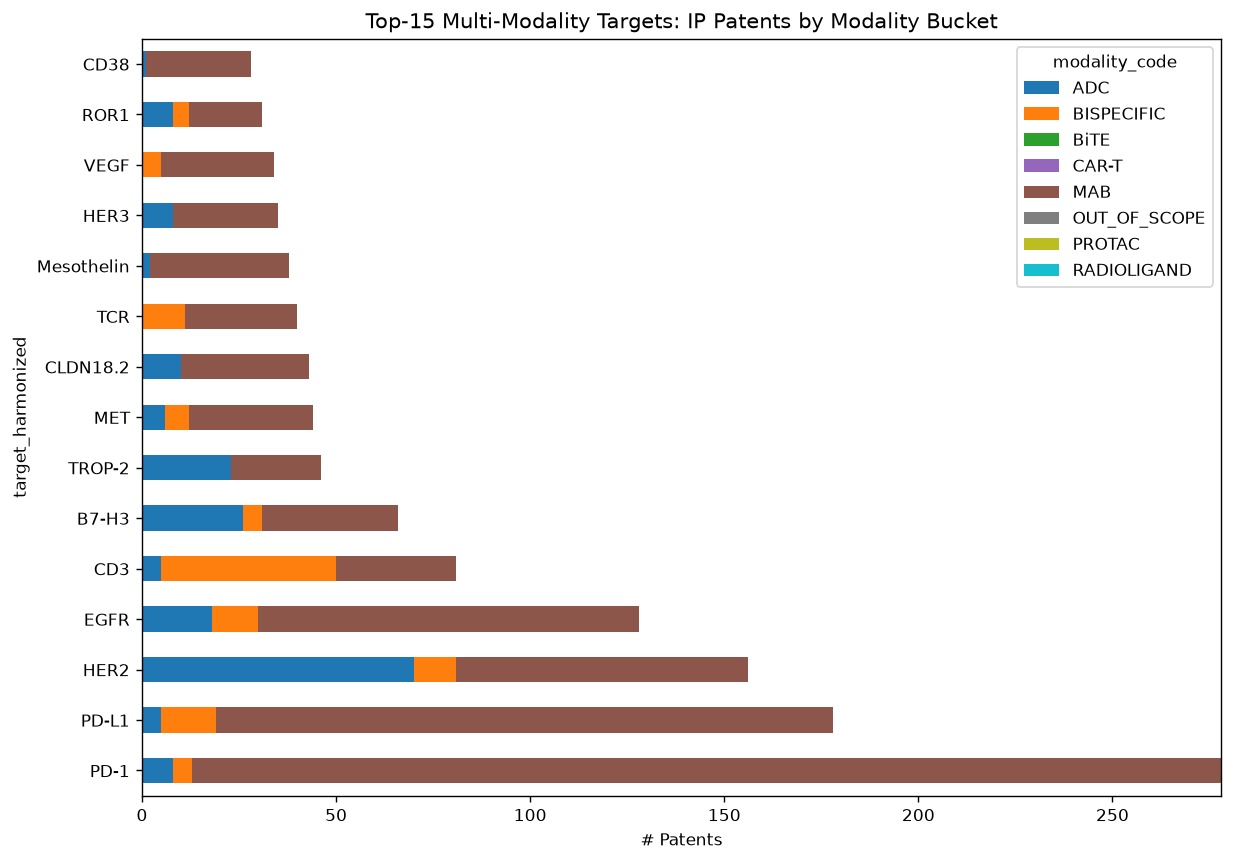

In [11]:
# A target can be crowded in one modality format and wide open in
# another (e.g. HER2 as a naked mAb vs HER2 as an ADC vs HER2 bispecific).
ip_mod = con.sql(f'''
    SELECT target_harmonized, modality_code, COUNT(*) AS n_patents
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1,2
''').df()
cl_mod = df.groupby(["target_h", "modality_code"]).size().reset_index(name="n_trials").rename(columns={"target_h": "target_harmonized"})

MODALITY_TRIANGULATION = ip_mod.merge(cl_mod, on=["target_harmonized", "modality_code"], how="outer").fillna(0)
MODALITY_TRIANGULATION["n_patents"] = MODALITY_TRIANGULATION["n_patents"].astype(int)
MODALITY_TRIANGULATION["n_trials"] = MODALITY_TRIANGULATION["n_trials"].astype(int)
MODALITY_TRIANGULATION = MODALITY_TRIANGULATION[
    (MODALITY_TRIANGULATION["n_patents"] + MODALITY_TRIANGULATION["n_trials"]) >= 5
].sort_values(["target_harmonized", "n_patents"], ascending=[True, False])
display(MODALITY_TRIANGULATION, name="entry11_modality_adjusted_triangulation")

# Targets with meaningfully different crowding pictures ACROSS modalities
# for the SAME target (e.g. crowded as mAb, thin as ADC).
pivot_p = MODALITY_TRIANGULATION.pivot_table(index="target_harmonized", columns="modality_code", values="n_patents", fill_value=0)
multi_modality_ip = pivot_p[(pivot_p > 0).sum(axis=1) >= 2]
print(f"{len(multi_modality_ip)} targets have IP activity in >=2 distinct modality buckets -- "
      f"a target 'crowded' at the antigen level may still have an open modality-specific niche.")

top_multi = multi_modality_ip.loc[multi_modality_ip.sum(axis=1).sort_values(ascending=False).head(15).index]
fig, ax = plt.subplots(figsize=(10, 7))
top_multi.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Top-15 Multi-Modality Targets: IP Patents by Modality Bucket"); ax.set_xlabel("# Patents")
plt.tight_layout()

## Entry 12 [PART B]: Timing Triangulation -- Patent Filing Year vs Clinical Trial Start Year, per Target


79 targets show clinical trials starting BEFORE any patent was filed (>=3 patents, possible FTO gap):


,target_harmonized,first_filing_year,latest_filing_year,n_patents,first_trial_year,latest_trial_year,n_trials,lag_years_filing_to_trial,lead_flag
82,EGFR,2010,2025,128,1985.0,2027.0,738,-25.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
124,GD2,2011,2025,19,1987.0,2026.0,82,-24.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
251,CD20,2010,2025,44,1990.0,2026.0,788,-20.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
151,CD3,2010,2025,81,1991.0,2026.0,28,-19.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
101,CD22,2014,2025,9,1997.0,2026.0,47,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
26,CD33,2013,2025,20,1996.0,2028.0,83,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
181,CEACAM5,2013,2025,18,2000.0,2025.0,8,-13.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
152,CD19|CD20,2012,2025,6,1999.0,2026.0,51,-13.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
127,CEA,2010,2023,15,1997.0,2026.0,50,-13.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
135,HER2,2010,2025,156,1997.0,2027.0,1171,-13.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap


,lead_flag,n_targets
0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap,79
1,IP LEADS (patent filed well before first trial),62
2,Roughly concurrent,32


,target_harmonized,first_trial_year,first_filing_year,lag_years_filing_to_trial,n_trials,n_patents
82,EGFR,1985.0,2010,-25.0,738,128
124,GD2,1987.0,2011,-24.0,82,19
251,CD20,1990.0,2010,-20.0,788,44
151,CD3,1991.0,2010,-19.0,28,81
101,CD22,1997.0,2014,-17.0,47,9
26,CD33,1996.0,2013,-17.0,83,20
127,CEA,1997.0,2010,-13.0,50,15
135,HER2,1997.0,2010,-13.0,1171,156
181,CEACAM5,2000.0,2013,-13.0,8,18
152,CD19|CD20,1999.0,2012,-13.0,51,6


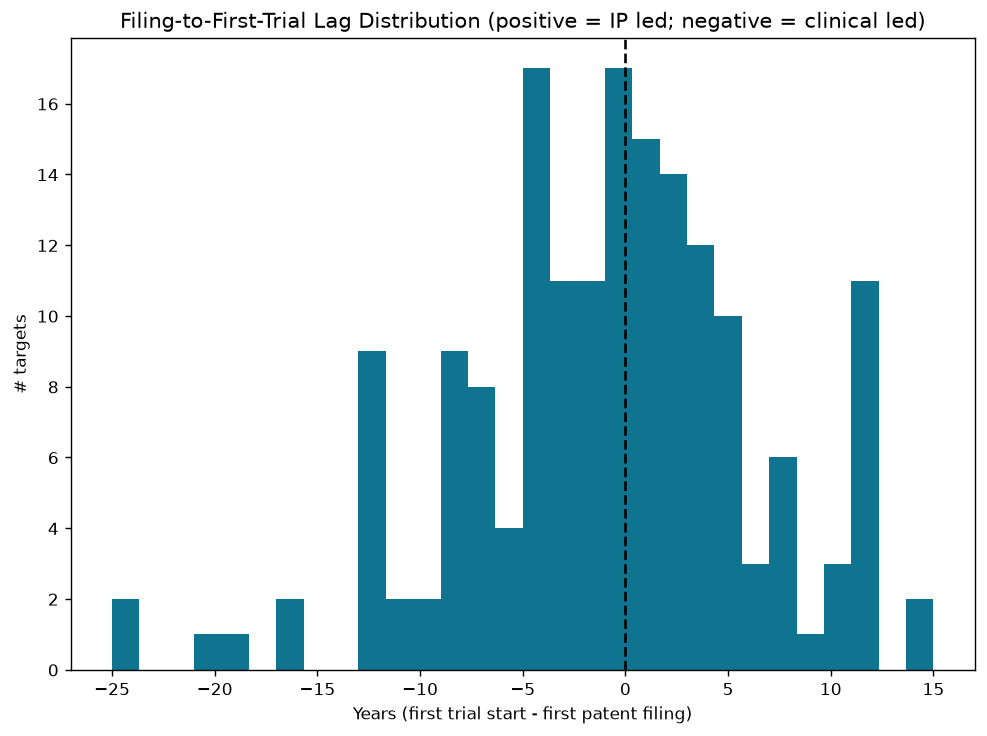

In [12]:
# Does IP consistently lead clinical activity, or are some targets being
# trialed with no (or very late) patent filing -- a freedom-to-operate flag?
ip_years = con.sql(f'''
    SELECT target_harmonized, MIN(filing_year) AS first_filing_year, MAX(filing_year) AS latest_filing_year, COUNT(*) AS n_patents
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1
''').df()
cl_years = df.groupby("target_h").agg(first_trial_year=("start_year", "min"),
                                       latest_trial_year=("start_year", "max"),
                                       n_trials=("nct", "count")).reset_index().rename(columns={"target_h": "target_harmonized"})

TIMING_LAG = ip_years.merge(cl_years, on="target_harmonized", how="inner")
TIMING_LAG = TIMING_LAG[TIMING_LAG["n_patents"] >= 3]
TIMING_LAG["lag_years_filing_to_trial"] = TIMING_LAG["first_trial_year"] - TIMING_LAG["first_filing_year"]

def lead_flag(lag):
    if pd.isna(lag):
        return "Unknown"
    if lag > 1:
        return "IP LEADS (patent filed well before first trial)"
    if lag < -1:
        return "CLINICAL LEADS (trial started well before first patent) -- possible FTO gap"
    return "Roughly concurrent"

TIMING_LAG["lead_flag"] = TIMING_LAG["lag_years_filing_to_trial"].apply(lead_flag)
display(TIMING_LAG.sort_values("lag_years_filing_to_trial"), name="entry12_timing_lag_full")
display(TIMING_LAG["lead_flag"].value_counts().rename_axis("lead_flag").reset_index(name="n_targets"), name="entry12_lead_flag_counts")

clinical_leads = TIMING_LAG[TIMING_LAG["lead_flag"].str.startswith("CLINICAL LEADS")].sort_values("lag_years_filing_to_trial")
print(f"\n{len(clinical_leads)} targets show clinical trials starting BEFORE any patent was filed (>=3 patents, possible FTO gap):")
display(clinical_leads[["target_harmonized", "first_trial_year", "first_filing_year", "lag_years_filing_to_trial", "n_trials", "n_patents"]],
        name="entry12_clinical_leads_targets")

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(TIMING_LAG["lag_years_filing_to_trial"].dropna(), bins=30, color="#0e7490")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Years (first trial start - first patent filing)"); ax.set_ylabel("# targets")
ax.set_title("Filing-to-First-Trial Lag Distribution (positive = IP led; negative = clinical led)")
plt.tight_layout()

## Entry 13 [PART B]: Clinically-Validated, Patent-Thin Targets -- Highest Business Case to File Now

154 targets have >=1 recorded clinical success AND <=10 IP patents -- clinical proof-of-concept already exists, but the IP field remains largely open. Strongest 'file now' business case.


,target_harmonized,n_trials,n_success,n_patents,n_assignees
76,CTLA-4|PD-1,351,16,9,7.0
163,PD-1|VEGF,138,16,7,7.0
176,TROP-2-Dxd,17,16,6,3.0
106,HER2-Dxd,22,13,10,2.0
49,CD30,118,8,9,5.0
118,HER2|PD-1,75,7,0,-
135,MET-MMAE,12,7,1,1.0
148,PD-1|CTLA-4,78,6,8,7.0
22,CD19|CD22,76,6,0,-
42,CD22,47,6,9,8.0


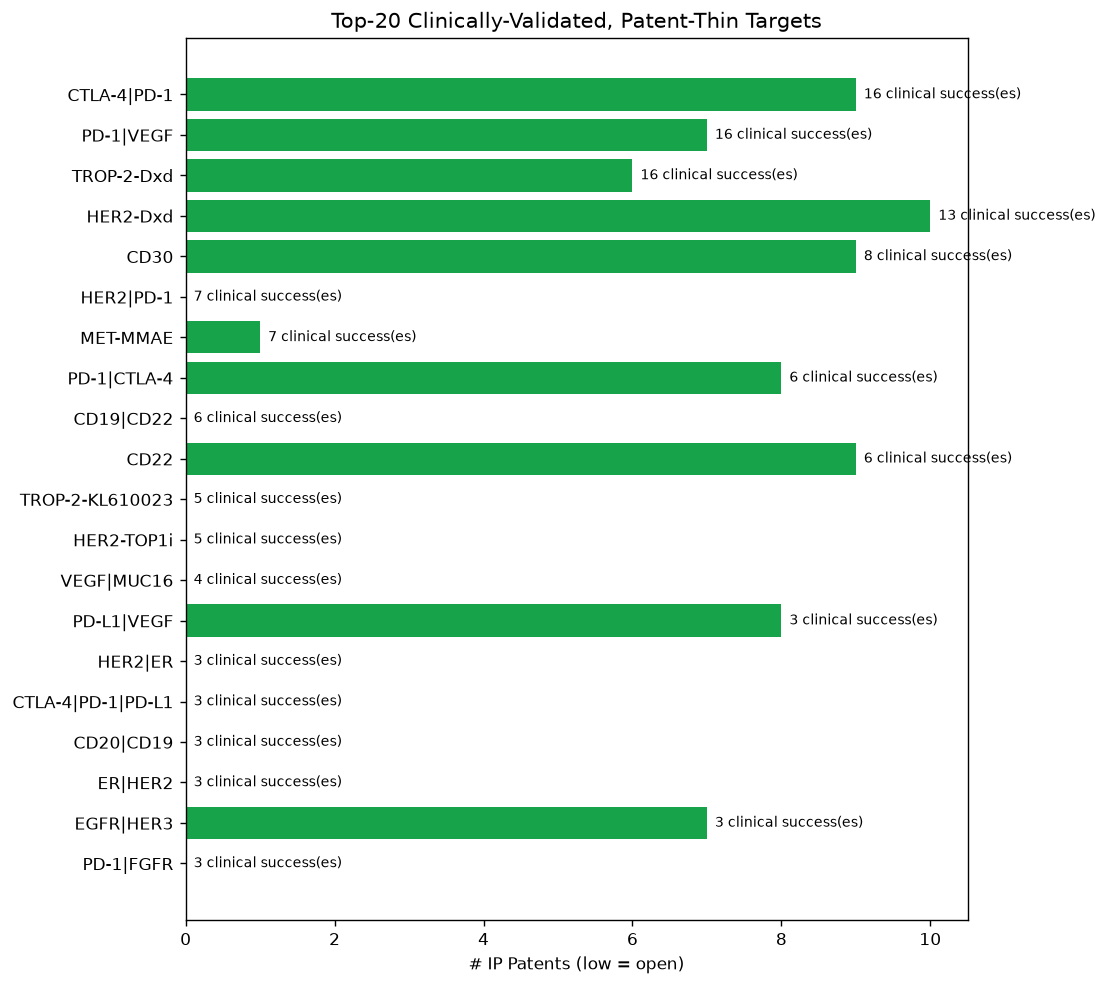

In [13]:
cl_validation = df.groupby("target_h").agg(
    n_trials=("nct", "count"),
    n_success=("outcome_bucket", lambda s: (s == "Success").sum()),
).reset_index().rename(columns={"target_h": "target_harmonized"})
cl_validation = cl_validation[cl_validation["n_success"] > 0]

ip_volume = con.sql(f'''
    SELECT target_harmonized, COUNT(*) AS n_patents, COUNT(DISTINCT current_assignee) AS n_assignees
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1
''').df()

VALIDATED_PATENT_THIN = cl_validation.merge(ip_volume, on="target_harmonized", how="left")
VALIDATED_PATENT_THIN["n_patents"] = VALIDATED_PATENT_THIN["n_patents"].fillna(0).astype(int)
VALIDATED_PATENT_THIN = VALIDATED_PATENT_THIN[VALIDATED_PATENT_THIN["n_patents"] <= 10].sort_values(
    ["n_success", "n_trials"], ascending=False)
display(VALIDATED_PATENT_THIN, name="entry13_validated_patent_thin")
print(f"{len(VALIDATED_PATENT_THIN)} targets have >=1 recorded clinical success AND <=10 IP patents -- "
      f"clinical proof-of-concept already exists, but the IP field remains largely open. Strongest 'file now' business case.")

fig, ax = plt.subplots(figsize=(9, 8))
top20 = VALIDATED_PATENT_THIN.head(20).iloc[::-1]
ax.barh(top20["target_harmonized"], top20["n_patents"], color="#16a34a")
for i, (n_s, n_p) in enumerate(zip(top20["n_success"], top20["n_patents"])):
    ax.text(n_p, i, f"  {int(n_s)} clinical success(es)", va="center", fontsize=8)
ax.set_xlabel("# IP Patents (low = open)"); ax.set_title("Top-20 Clinically-Validated, Patent-Thin Targets")
plt.tight_layout()

## Entry 14 [PART B]: Patent-Crowded, Clinically-Unproven Targets -- Highest Litigation / FTO Risk If We Enter

59 targets have >=10 IP patents but ZERO recorded clinical success (no trials, ongoing-only, or failed-only) -- highest patent-litigation exposure for the least proven biology.


,target_harmonized,n_patents,n_trials,n_success,n_failure
85,CD3,81.0,28.0,0.0,5.0
0,CD47,61.0,16.0,0.0,7.0
36,TIGIT,49.0,12.0,0.0,7.0
50,TCR,45.0,20.0,0.0,7.0
77,CD73,44.0,7.0,0.0,0.0
70,OX40,44.0,3.0,0.0,2.0
57,CD137,44.0,14.0,0.0,5.0
94,TNF-alpha,40.0,1.0,0.0,1.0
39,CCR8,36.0,3.0,0.0,0.0
61,ROR1,31.0,12.0,0.0,5.0


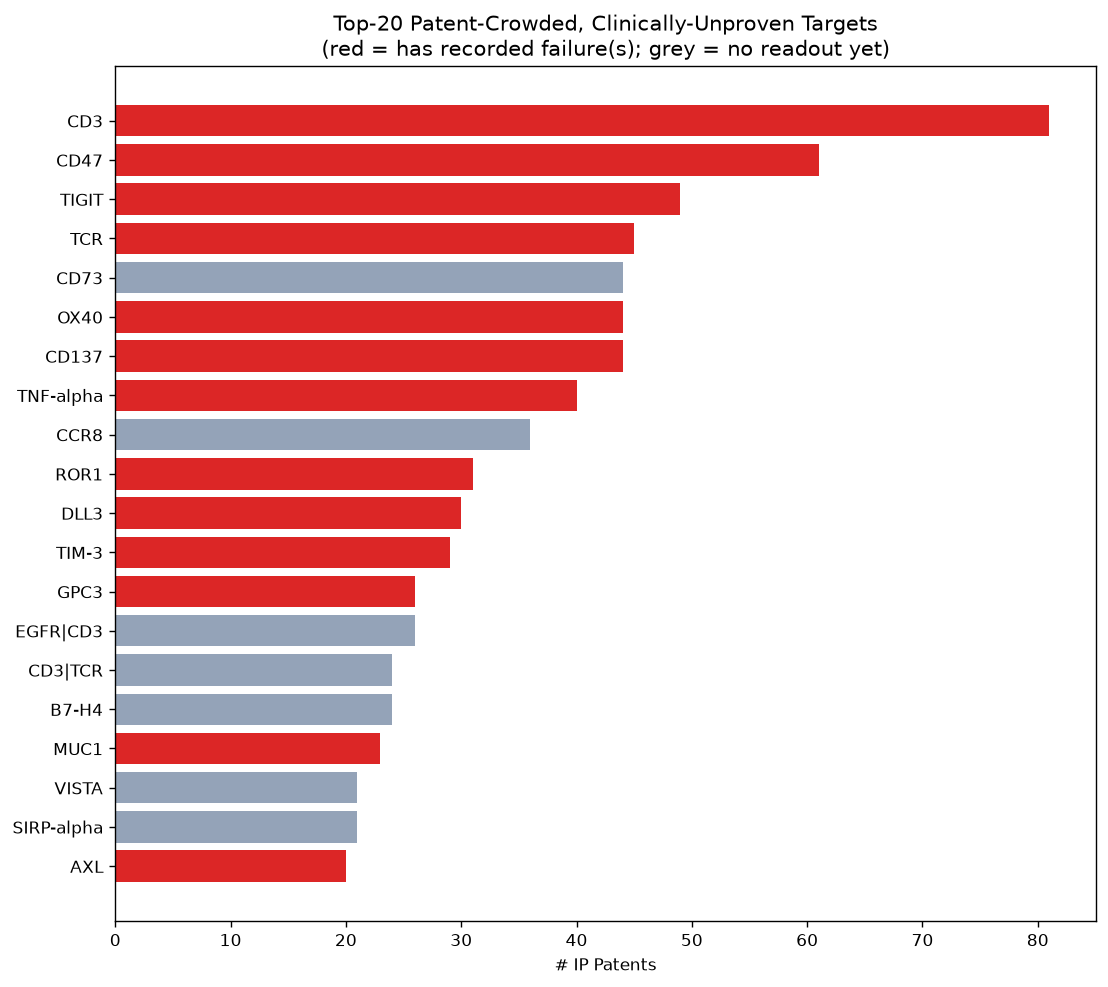

In [14]:
ip_hhi = con.sql(f'''
    WITH base AS (
      SELECT target_harmonized AS t, current_assignee, COUNT(*) AS n
      FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1,2
    ),
    tot AS (SELECT t, SUM(n) AS total FROM base GROUP BY 1 HAVING SUM(n) >= 10)
    SELECT b.t AS target_harmonized, MAX(total) AS n_patents
    FROM base b JOIN tot ON b.t = tot.t GROUP BY 1
''').df()

cl_unproven = df.groupby("target_h").agg(
    n_trials=("nct", "count"),
    n_success=("outcome_bucket", lambda s: (s == "Success").sum()),
    n_failure=("outcome_bucket", lambda s: (s == "Failure").sum()),
).reset_index().rename(columns={"target_h": "target_harmonized"})

PATENT_CROWDED_UNPROVEN = ip_hhi.merge(cl_unproven, on="target_harmonized", how="left")
PATENT_CROWDED_UNPROVEN[["n_trials", "n_success", "n_failure"]] = PATENT_CROWDED_UNPROVEN[["n_trials", "n_success", "n_failure"]].fillna(0)
PATENT_CROWDED_UNPROVEN = PATENT_CROWDED_UNPROVEN[PATENT_CROWDED_UNPROVEN["n_success"] == 0].sort_values("n_patents", ascending=False)
display(PATENT_CROWDED_UNPROVEN, name="entry14_patent_crowded_unproven")
print(f"{len(PATENT_CROWDED_UNPROVEN)} targets have >=10 IP patents but ZERO recorded clinical success "
      f"(no trials, ongoing-only, or failed-only) -- highest patent-litigation exposure for the least proven biology.")

fig, ax = plt.subplots(figsize=(9, 8))
top20 = PATENT_CROWDED_UNPROVEN.head(20).iloc[::-1]
colors = ["#dc2626" if f > 0 else "#94a3b8" for f in top20["n_failure"]]
ax.barh(top20["target_harmonized"], top20["n_patents"], color=colors)
ax.set_xlabel("# IP Patents"); ax.set_title("Top-20 Patent-Crowded, Clinically-Unproven Targets\n(red = has recorded failure(s); grey = no readout yet)")
plt.tight_layout()

## Entry 15 [PART B]: The CAR-T IP Blind Spot -- Clinically Active CAR-T Targets With No Antibody-Modality Patent Tag

221 distinct CAR-T targets in the clinical data; 151 of them have NO matching antibody-modality IP record at all in ip_final_version3.csv -- a genuine freedom-to-operate blind spot (this dataset simply does not cover CAR-T construct patents), NOT necessarily a real absence of IP risk.


,target_harmonized,n_cart_trials,n_patents,ip_modalities,ip_coverage
0,CD19,393,31,"MAB, ADC","Antibody-modality IP exists under: MAB, ADC"
1,BCMA,115,28,"BISPECIFIC, ADC, MAB","Antibody-modality IP exists under: BISPECIFIC, ADC, MAB"
2,CD19|CD22,75,0,-,NO antibody-modality IP found for this target at all
3,Mesothelin,41,39,"MAB, ADC, BISPECIFIC","Antibody-modality IP exists under: MAB, ADC, BISPECIFIC"
4,GPC3,40,26,"MAB, BISPECIFIC, ADC","Antibody-modality IP exists under: MAB, BISPECIFIC, ADC"
5,BCMA|CD19,40,0,-,NO antibody-modality IP found for this target at all
6,CD19|CD20,38,6,BISPECIFIC,Antibody-modality IP exists under: BISPECIFIC
7,B7-H3,35,66,"MAB, ADC, BISPECIFIC","Antibody-modality IP exists under: MAB, ADC, BISPECIFIC"
8,CD70,29,13,MAB,Antibody-modality IP exists under: MAB
9,PD-1,29,278,"ADC, BISPECIFIC, MAB","Antibody-modality IP exists under: ADC, BISPECIFIC, MAB"


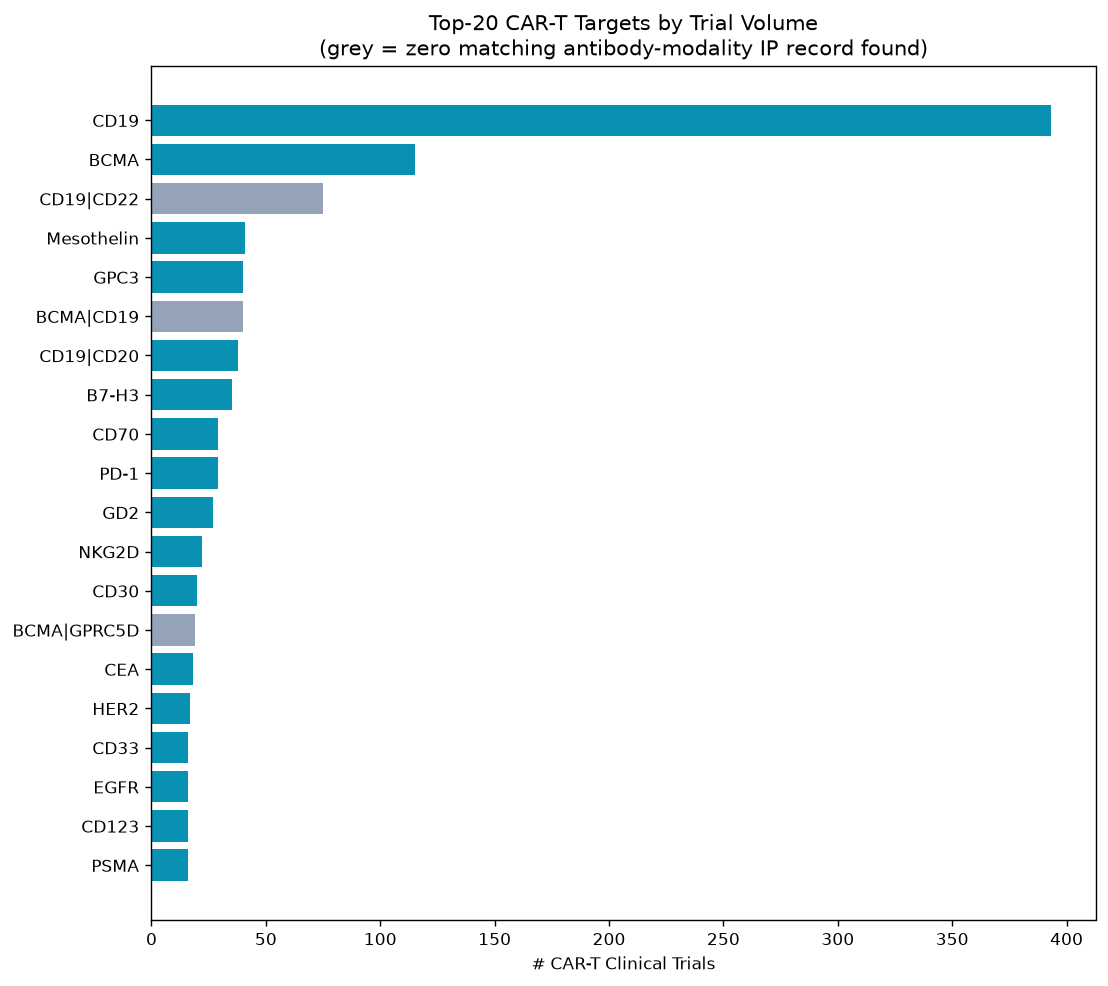

In [15]:
# ip_final_version3.csv has NO CAR-T modality_code at all (antibody
# patent filings rarely file as "CAR-T" per se) -- but a CAR-T binder
# domain is usually antibody-derived, so the SAME target may still show
# up in IP data under MAB/BISPECIFIC/ADC. This checks whether that's true.
cart_targets = df[df["modality_code"] == "CAR-T"].groupby("target_h").size().reset_index(name="n_cart_trials").rename(
    columns={"target_h": "target_harmonized"}).sort_values("n_cart_trials", ascending=False)

ip_any = con.sql(f'''
    SELECT target_harmonized, COUNT(*) AS n_patents, STRING_AGG(DISTINCT modality_code, ', ') AS ip_modalities
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL GROUP BY 1
''').df()

CART_BLIND_SPOT = cart_targets.merge(ip_any, on="target_harmonized", how="left")
CART_BLIND_SPOT["n_patents"] = CART_BLIND_SPOT["n_patents"].fillna(0).astype(int)
CART_BLIND_SPOT["ip_coverage"] = np.where(CART_BLIND_SPOT["n_patents"] == 0,
                                           "NO antibody-modality IP found for this target at all",
                                           "Antibody-modality IP exists under: " + CART_BLIND_SPOT["ip_modalities"].fillna(""))
display(CART_BLIND_SPOT.head(30), name="entry15_cart_blind_spot")

n_no_ip = (CART_BLIND_SPOT["n_patents"] == 0).sum()
print(f"{len(CART_BLIND_SPOT)} distinct CAR-T targets in the clinical data; {n_no_ip} of them have NO matching "
      f"antibody-modality IP record at all in ip_final_version3.csv -- a genuine freedom-to-operate blind spot "
      f"(this dataset simply does not cover CAR-T construct patents), NOT necessarily a real absence of IP risk.")

fig, ax = plt.subplots(figsize=(9, 8))
top20 = CART_BLIND_SPOT.head(20).iloc[::-1]
colors = ["#94a3b8" if p == 0 else "#0891b2" for p in top20["n_patents"]]
ax.barh(top20["target_harmonized"], top20["n_cart_trials"], color=colors)
ax.set_xlabel("# CAR-T Clinical Trials"); ax.set_title("Top-20 CAR-T Targets by Trial Volume\n(grey = zero matching antibody-modality IP record found)")
plt.tight_layout()

## Entry 16 [PART B]: Sponsor <-> Assignee Overlap -- Same Company Patenting AND Trialing the Same Target

159 (target, company) pairs where the SAME company (approximate name-normalized match) both holds patents AND runs trials on that target -- the strongest possible competitive signal: they believe in the biology enough to both file and trial it themselves.


,target_harmonized,current_assignee,n_patents,lead_sponsor_golden,n_trials
96,PD-1,"REGENERON PHARMACEUTICALS, INC.",11,Regeneron Pharmaceuticals,14
100,HER2-MMAE,"REMEGEN CO., LTD.",9,"RemeGen Co., Ltd.",7
71,CD19,MORPHOSYS AG,7,MorphoSys AG,5
135,MUC16|CD3,"REGENERON PHARMACEUTICALS, INC.",7,Regeneron Pharmaceuticals,1
148,CD20|CD3,"REGENERON PHARMACEUTICALS, INC.",6,Regeneron Pharmaceuticals,7
12,CEACAM5,SANOFI,6,Sanofi,3
149,BCMA|CD3,"REGENERON PHARMACEUTICALS, INC.",5,Regeneron Pharmaceuticals,5
57,CD30,SEAGEN INC.,4,Seagen Inc.,15
18,PD-L1,MEDIMMUNE LIMITED,4,MedImmune LLC,3
89,PD-1,"INNOVENT BIOLOGICS (SUZHOU) CO., LTD.",4,Innovent Biologics (Suzhou) Co. Ltd.,3


,n_targets,total_patents,total_trials
current_assignee,,,
MEMORIAL SLOAN KETTERING CANCER CENTER,5,6,22
MEDIMMUNE LIMITED,5,9,7
AMGEN INC.,5,6,38
PFIZER INC.,5,7,28
"REGENERON PHARMACEUTICALS, INC.",5,30,31
SEAGEN INC.,5,11,24
NOVARTIS AG,4,6,21
ELI LILLY AND COMPANY,4,6,64
CELGENE CORPORATION,3,4,10


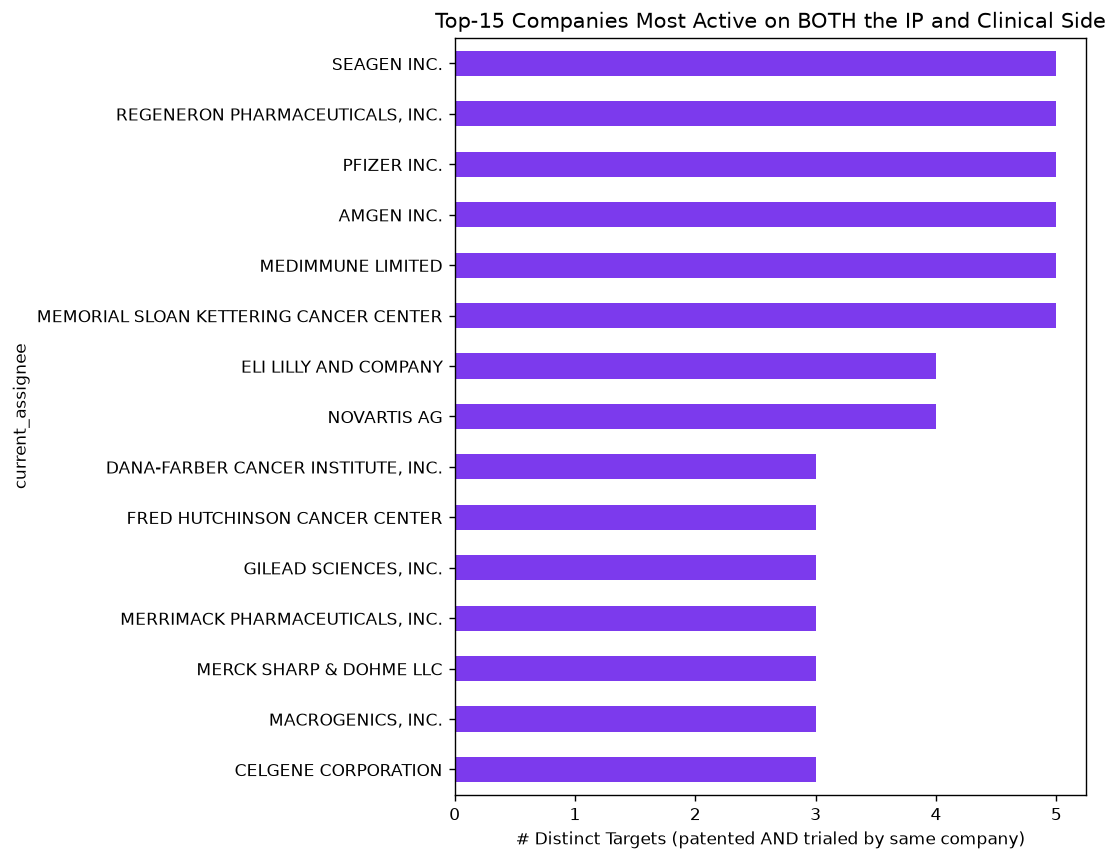

In [16]:
# Approximate, name-normalized matching (company legal-suffix noise means
# exact string equality would under-count) -- strip common corporate
# suffixes/punctuation and uppercase before comparing. Caveat clearly
# flagged: this is an approximate signal, not an exact entity match.
SUFFIX_RE = re.compile(r"\b(INC|LLC|LTD|LIMITED|CORP|CORPORATION|CO|GMBH|AG|SA|SAS|PLC|NV|BV|KG|SPA|"
                       r"PHARMACEUTICALS?|PHARMA|THERAPEUTICS|BIOSCIENCES|BIOTECH|BIOPHARMA|HOLDINGS|GROUP)\.?\b")

def norm_name(s):
    if pd.isna(s):
        return None
    s = str(s).upper()
    s = re.sub(r"[.,]", " ", s)
    s = SUFFIX_RE.sub("", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else None

ip_assignee = con.sql(f'''
    SELECT target_harmonized, current_assignee, COUNT(*) AS n_patents
    FROM read_csv_auto('{IP_CSV}') WHERE target_harmonized IS NOT NULL AND current_assignee IS NOT NULL
    GROUP BY 1,2
''').df()
ip_assignee["assignee_norm"] = ip_assignee["current_assignee"].apply(norm_name)

cl_sponsor = df.groupby(["target_h", "lead_sponsor_golden"]).size().reset_index(name="n_trials").rename(columns={"target_h": "target_harmonized"})
cl_sponsor["sponsor_norm"] = cl_sponsor["lead_sponsor_golden"].apply(norm_name)

SPONSOR_ASSIGNEE_OVERLAP = ip_assignee.merge(cl_sponsor, left_on=["target_harmonized", "assignee_norm"],
                                              right_on=["target_harmonized", "sponsor_norm"], how="inner")
SPONSOR_ASSIGNEE_OVERLAP = SPONSOR_ASSIGNEE_OVERLAP[["target_harmonized", "current_assignee", "n_patents",
                                                      "lead_sponsor_golden", "n_trials"]].sort_values(
    ["n_patents", "n_trials"], ascending=False)
display(SPONSOR_ASSIGNEE_OVERLAP, name="entry16_sponsor_assignee_overlap")
print(f"{len(SPONSOR_ASSIGNEE_OVERLAP)} (target, company) pairs where the SAME company (approximate "
      f"name-normalized match) both holds patents AND runs trials on that target -- the strongest possible "
      f"competitive signal: they believe in the biology enough to both file and trial it themselves.")

top_companies = SPONSOR_ASSIGNEE_OVERLAP.groupby("current_assignee").agg(
    n_targets=("target_harmonized", "nunique"), total_patents=("n_patents", "sum"), total_trials=("n_trials", "sum")
).sort_values("n_targets", ascending=False).head(15)
display(top_companies, name="entry16_top_companies_both_sides")

fig, ax = plt.subplots(figsize=(9, 7))
top_companies.sort_values("n_targets")["n_targets"].plot(kind="barh", ax=ax, color="#7c3aed")
ax.set_xlabel("# Distinct Targets (patented AND trialed by same company)")
ax.set_title("Top-15 Companies Most Active on BOTH the IP and Clinical Side")
plt.tight_layout()

## Entry 17 [PART B]: Solid-Tumor-Indication Whitespace/Crowding, Computed Directly From Raw Data

,tumor_type,n_patents,n_targets_patented,n_trials,n_targets_trialed,indication_quadrant
12,Lung_Other,1603,605,2853,487,Broadly Crowded (high patent AND high trial volume)
15,NSCLC,0,0,2283,418,"Split (open on one axis, saturated on the other)"
3,Breast,1526,598,2050,313,Broadly Crowded (high patent AND high trial volume)
21,SCLC,0,0,2003,384,"Split (open on one axis, saturated on the other)"
5,Colorectal,1347,565,1361,253,Broadly Crowded (high patent AND high trial volume)
7,Gastric_Esophageal,1876,506,1059,234,Broadly Crowded (high patent AND high trial volume)
10,HNSCC,926,412,883,184,"Split (open on one axis, saturated on the other)"
13,Melanoma,1259,559,734,144,Broadly Crowded (high patent AND high trial volume)
18,Pancreatic,1266,550,575,179,Broadly Crowded (high patent AND high trial volume)
17,Ovarian,1275,548,573,206,Broadly Crowded (high patent AND high trial volume)


,tumor_type,indication_quadrant
12,Lung_Other,Broadly Crowded (high patent AND high trial volume)
15,NSCLC,"Split (open on one axis, saturated on the other)"
3,Breast,Broadly Crowded (high patent AND high trial volume)
21,SCLC,"Split (open on one axis, saturated on the other)"
5,Colorectal,Broadly Crowded (high patent AND high trial volume)
7,Gastric_Esophageal,Broadly Crowded (high patent AND high trial volume)
10,HNSCC,"Split (open on one axis, saturated on the other)"
13,Melanoma,Broadly Crowded (high patent AND high trial volume)
18,Pancreatic,Broadly Crowded (high patent AND high trial volume)
17,Ovarian,Broadly Crowded (high patent AND high trial volume)


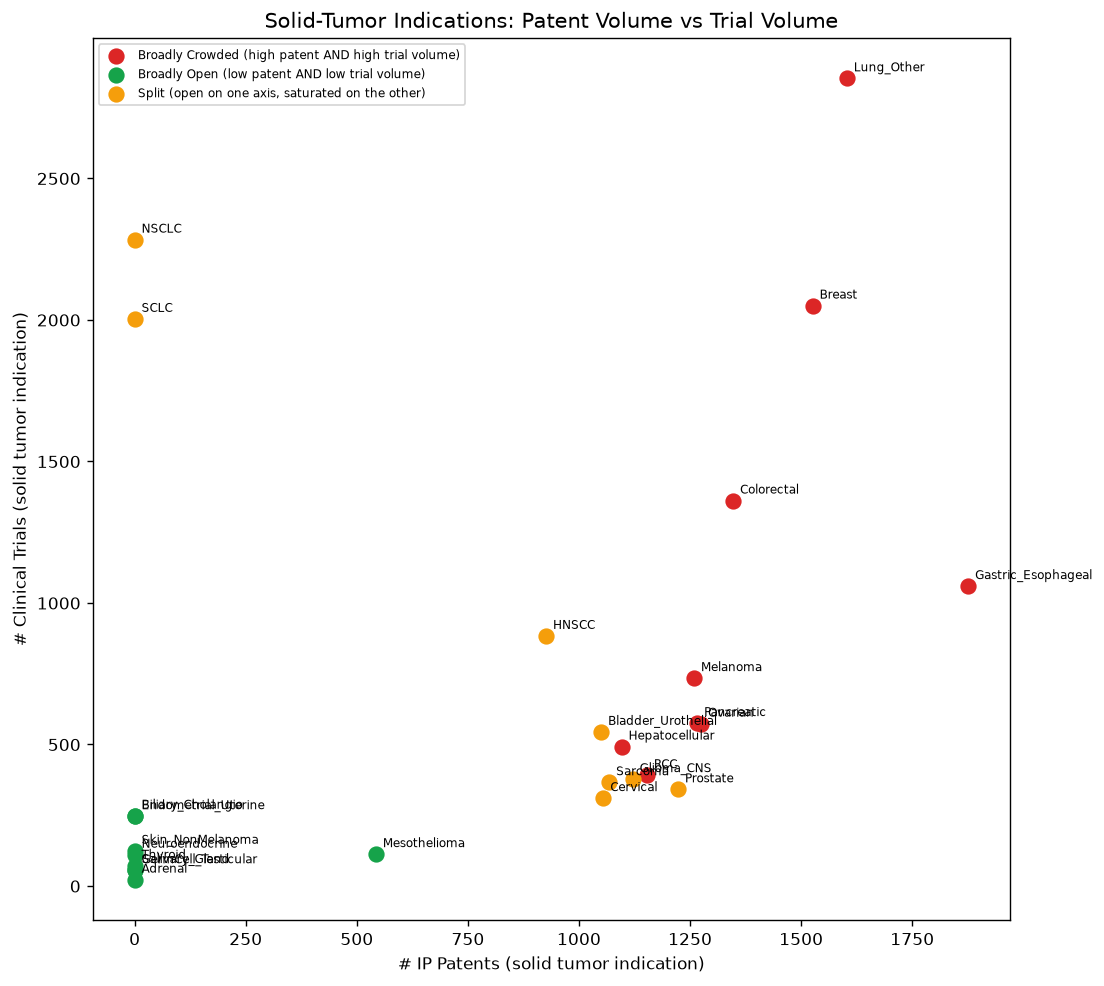

In [17]:
# Independent of Part A's notebook-tier reproduction: rank every solid
# tumor indication by total patent volume vs total trial volume across
# ALL qualifying targets (>=3 patents or >=5 trials), to see which
# indications are broadly open vs broadly saturated on EITHER axis.
ip_ind_totals = ip_junction.groupby("tumor_type").agg(n_patents=("target_h", "count"), n_targets_patented=("target_h", "nunique")).reset_index()
cl_ind_totals = cl_by_target_tumor.groupby("tumor_type").agg(n_trials=("n_trials", "sum"), n_targets_trialed=("target_h", "nunique")).reset_index()

INDICATION_RAW_TRIANGULATION = ip_ind_totals.merge(cl_ind_totals, on="tumor_type", how="outer").fillna(0)
for c in ["n_patents", "n_targets_patented", "n_trials", "n_targets_trialed"]:
    INDICATION_RAW_TRIANGULATION[c] = INDICATION_RAW_TRIANGULATION[c].astype(int)
INDICATION_RAW_TRIANGULATION = INDICATION_RAW_TRIANGULATION.sort_values("n_trials", ascending=False)
display(INDICATION_RAW_TRIANGULATION, name="entry17_indication_raw_triangulation")

p_med = INDICATION_RAW_TRIANGULATION["n_patents"].median()
t_med = INDICATION_RAW_TRIANGULATION["n_trials"].median()

def ind_quadrant(row):
    if row["n_patents"] >= p_med and row["n_trials"] >= t_med:
        return "Broadly Crowded (high patent AND high trial volume)"
    if row["n_patents"] < p_med and row["n_trials"] < t_med:
        return "Broadly Open (low patent AND low trial volume)"
    return "Split (open on one axis, saturated on the other)"

INDICATION_RAW_TRIANGULATION["indication_quadrant"] = INDICATION_RAW_TRIANGULATION.apply(ind_quadrant, axis=1)
display(INDICATION_RAW_TRIANGULATION[["tumor_type", "indication_quadrant"]], name="entry17_indication_quadrant_labels")

fig, ax = plt.subplots(figsize=(9, 8))
colors_map = {"Broadly Crowded (high patent AND high trial volume)": "#dc2626",
              "Broadly Open (low patent AND low trial volume)": "#16a34a",
              "Split (open on one axis, saturated on the other)": "#f59e0b"}
for label, sub in INDICATION_RAW_TRIANGULATION.groupby("indication_quadrant"):
    ax.scatter(sub["n_patents"], sub["n_trials"], label=label, color=colors_map[label], s=70)
for _, row in INDICATION_RAW_TRIANGULATION.iterrows():
    ax.annotate(row["tumor_type"], (row["n_patents"], row["n_trials"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("# IP Patents (solid tumor indication)"); ax.set_ylabel("# Clinical Trials (solid tumor indication)")
ax.set_title("Solid-Tumor Indications: Patent Volume vs Trial Volume"); ax.legend(fontsize=7)
plt.tight_layout()

## Entry 18: Executive Summary & Key Findings

In [18]:
n_both = len(MERGED_TIERS[MERGED_TIERS["_merge"] == "both"])
n_match = (MERGED_TIERS[MERGED_TIERS["_merge"] == "both"]["ip_tier"] == MERGED_TIERS[MERGED_TIERS["_merge"] == "both"]["cl_tier"]).sum()
n_crowded_both = len(crowded_both)
n_ws_both = len(ws_both)
n_ip_crowded_not_caught = len(ip_crowded_not_caught)
n_cl_ws = len(ws_clinical)
n_clinical_leads = len(clinical_leads)
n_validated_thin = len(VALIDATED_PATENT_THIN)
n_crowded_unproven = len(PATENT_CROWDED_UNPROVEN)
n_cart_no_ip = int((CART_BLIND_SPOT["n_patents"] == 0).sum())
n_overlap_companies = SPONSOR_ASSIGNEE_OVERLAP["current_assignee"].nunique()

print("EXECUTIVE SUMMARY -- Clinical x IP Triangulation, Antibody Therapeutics in Oncology")
print("=" * 88)
print(f"Universe: {IP_QUADRANT.shape[0]} IP-tiered targets (>=3 patents) x {CL_TIER.shape[0]} clinical-tiered "
      f"targets; {n_both} targets qualify for a tier on BOTH sides ({n_match} agree, {n_both - n_match} disagree).")
print()
print("PART A -- Prior-Notebook Cross-Comparison:")
print(f"  - {n_crowded_both} targets are CROWDED in both notebooks (de-risked biology, but a contested IP field): "
      f"{', '.join(crowded_both['target_harmonized'].head(9).tolist())}")
print(f"  - {n_ws_both} targets are WHITESPACE in both (highest upside, highest uncertainty).")
print(f"  - {n_ip_crowded_not_caught} targets are IP-Crowded but clinical activity has NOT caught up -- "
      f"patent filers are racing ahead of clinical proof.")
print(f"  - Of {n_cl_ws} clinical Phase-1/2 whitespace targets, "
      f"{(ws_clinical['ip_status']=='No IP patent data at all (target absent from IP universe)').sum() + (ws_clinical['ip_status'].isin(['Whitespace (High Risk)','Medium'])).sum()} "
      f"are ALSO not IP-crowded -- truly open candidates; the rest sit on a crowded patent position despite "
      f"looking clinically clean.")
print()
print("PART B -- Raw-Data Triangulation:")
print(f"  - {n_clinical_leads} targets show clinical trials starting BEFORE any patent filing (>=3 patents) -- "
      f"a potential freedom-to-operate gap worth legal review before committing.")
print(f"  - {n_validated_thin} targets have >=1 clinical success AND <=10 patents -- the strongest 'file now' case.")
print(f"  - {n_crowded_unproven} targets have >=10 patents and ZERO recorded clinical success -- highest "
      f"patent-litigation exposure for the least proven biology.")
print(f"  - {n_cart_no_ip} of {len(CART_BLIND_SPOT)} clinically active CAR-T targets have no matching "
      f"antibody-modality IP record at all -- a dataset coverage gap, not a real absence of risk.")
print(f"  - {n_overlap_companies} companies are found patenting AND trialing the same target under an "
      f"approximate name match -- the strongest observed competitive-conviction signal.")
print()
print("STRATEGIC IMPLICATION: the single most actionable output of this triangulation is the "
      "'clinically validated, patent-thin' list (Entry 13) crossed with the 'clinical Phase-1/2 whitespace, "
      "IP not crowded' list (Entry 8) -- these are the targets where both datasets independently agree "
      "there is room to move, which is the balanced (patent-freedom + clinical-validation) framing requested.")

EXECUTIVE SUMMARY -- Clinical x IP Triangulation, Antibody Therapeutics in Oncology
Universe: 338 IP-tiered targets (>=3 patents) x 907 clinical-tiered targets; 128 targets qualify for a tier on BOTH sides (62 agree, 66 disagree).

PART A -- Prior-Notebook Cross-Comparison:
  - 9 targets are CROWDED in both notebooks (de-risked biology, but a contested IP field): PD-1, PD-L1, HER2, EGFR, CTLA-4, TROP-2, CD20, VEGF, CD19
  - 25 targets are WHITESPACE in both (highest upside, highest uncertainty).
  - 21 targets are IP-Crowded but clinical activity has NOT caught up -- patent filers are racing ahead of clinical proof.
  - Of 686 clinical Phase-1/2 whitespace targets, 683 are ALSO not IP-crowded -- truly open candidates; the rest sit on a crowded patent position despite looking clinically clean.

PART B -- Raw-Data Triangulation:
  - 79 targets show clinical trials starting BEFORE any patent filing (>=3 patents) -- a potential freedom-to-operate gap worth legal review before committing.
 

## Entry 19 [PART C -- TUMOR TYPE DEEP DIVE]: Validated & Patent-Thin Targets, by Solid-Tumor Indication

407 (target, solid-tumor-indication) pairs have >=1 recorded clinical success in that SPECIFIC indication AND <=5 patents tagged to that same indication -- the sharpest 'file now, this indication' business case (target-level thinness in Entry 13 can mask indication-level crowding, and vice versa).


,target_harmonized,tumor_type,n_trials,n_success,n_patents
324,PD-1,NSCLC,562,233,0
330,PD-1,SCLC,492,200,0
474,VEGF,Lung_Other,272,191,2
476,VEGF,NSCLC,186,140,0
482,VEGF,SCLC,160,120,0
398,PD-L1,NSCLC,195,59,0
403,PD-L1,SCLC,191,48,0
88,CTLA-4,Lung_Other,28,22,4
490,VEGFR2,Lung_Other,27,22,0
90,CTLA-4,NSCLC,24,19,0


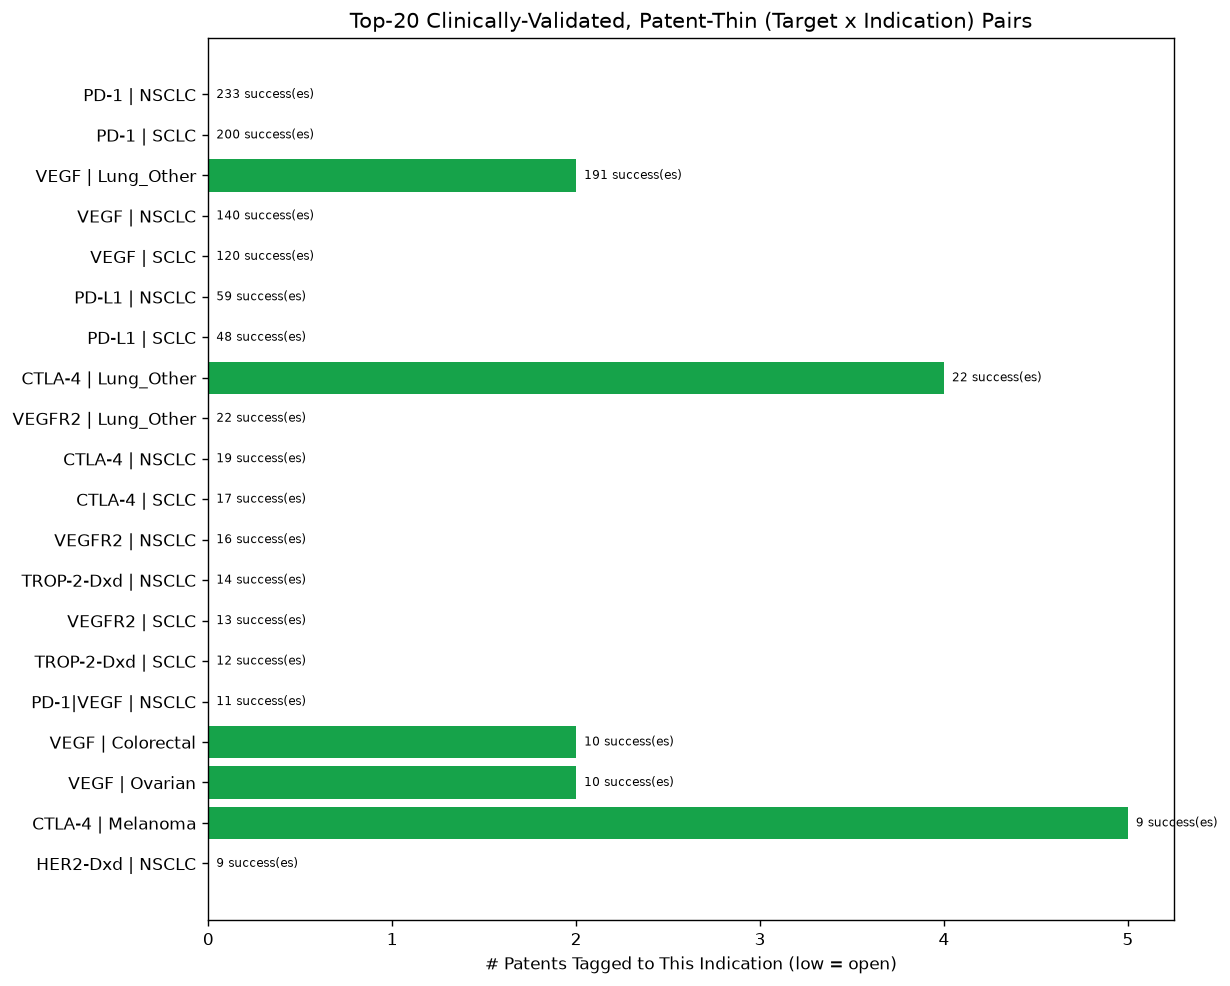

In [19]:
# Entries 10-16 (Part B) were all computed at the TARGET level, pooling
# every indication together. This Part C re-cuts the two highest-value
# business calls -- "file now" (this entry) and "FTO risk" (next entry)
# -- at the (target, solid-tumor-indication) level, reusing the same
# canonical tumor-type taxonomy and the ip_by_target_tumor /
# tumor_junction structures built in Entry 9 / Entry 2. A target can look
# clinically validated overall (Entry 13) while still being unproven in
# ONE specific indication that carries a heavy patent position, and vice
# versa -- that nuance only shows up at this granularity.
cl_val_by_tumor = tumor_junction.groupby(["target_h", "tumor_type"]).agg(
    n_trials=("nct", "count"),
    n_success=("outcome_bucket", lambda s: (s == "Success").sum()),
).reset_index()
cl_val_by_tumor = cl_val_by_tumor[
    (cl_val_by_tumor["n_success"] > 0) & ~cl_val_by_tumor["tumor_type"].str.startswith("Hematologic")
    & (cl_val_by_tumor["tumor_type"] != "Solid_Tumor_Basket")
]

VALIDATED_PATENT_THIN_BY_TUMOR = cl_val_by_tumor.merge(ip_by_target_tumor, on=["target_h", "tumor_type"], how="left")
VALIDATED_PATENT_THIN_BY_TUMOR["n_patents"] = VALIDATED_PATENT_THIN_BY_TUMOR["n_patents"].fillna(0).astype(int)
VALIDATED_PATENT_THIN_BY_TUMOR = VALIDATED_PATENT_THIN_BY_TUMOR.rename(columns={"target_h": "target_harmonized"})
VALIDATED_PATENT_THIN_BY_TUMOR = VALIDATED_PATENT_THIN_BY_TUMOR[VALIDATED_PATENT_THIN_BY_TUMOR["n_patents"] <= 5].sort_values(
    ["n_success", "n_trials"], ascending=False)
display(VALIDATED_PATENT_THIN_BY_TUMOR, name="entry19_validated_patent_thin_by_tumor")
print(f"{len(VALIDATED_PATENT_THIN_BY_TUMOR)} (target, solid-tumor-indication) pairs have >=1 recorded clinical "
      f"success in that SPECIFIC indication AND <=5 patents tagged to that same indication -- the sharpest "
      f"'file now, this indication' business case (target-level thinness in Entry 13 can mask indication-level "
      f"crowding, and vice versa).")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = VALIDATED_PATENT_THIN_BY_TUMOR.head(20).iloc[::-1]
labels = top20["target_harmonized"] + " | " + top20["tumor_type"]
ax.barh(labels, top20["n_patents"], color="#16a34a")
for i, (n_s, n_p) in enumerate(zip(top20["n_success"], top20["n_patents"])):
    ax.text(n_p, i, f"  {int(n_s)} success(es)", va="center", fontsize=7)
ax.set_xlabel("# Patents Tagged to This Indication (low = open)")
ax.set_title("Top-20 Clinically-Validated, Patent-Thin (Target x Indication) Pairs")
plt.tight_layout()

## Entry 20 [PART C -- TUMOR TYPE DEEP DIVE]: Patent-Crowded & Clinically-Unproven Targets, by Solid-Tumor Indication (FTO Risk by Indication)

808 (target, solid-tumor-indication) pairs have >=5 patents tagged to that indication but ZERO recorded clinical success in that SAME indication -- the sharpest FTO/litigation-exposure view, since a target can look clinically proven overall (Entry 14) while still being unproven in a SPECIFIC, heavily patented indication.


,target_harmonized,tumor_type,n_patents,n_trials,n_success,n_failure
122,CD3,Gastric_Esophageal,55,2.0,0.0,0.0
127,CD3,Melanoma,38,1.0,0.0,0.0
119,CD3,Breast,36,3.0,0.0,2.0
126,CD3,Lung_Other,36,1.0,0.0,1.0
129,CD3,Ovarian,35,2.0,0.0,1.0
121,CD3,Colorectal,34,2.0,0.0,0.0
114,CD20|CD3,Prostate,33,0.0,0.0,0.0
130,CD3,Pancreatic,31,0.0,0.0,0.0
131,CD3,Prostate,31,2.0,0.0,1.0
123,CD3,Glioma_CNS,30,1.0,0.0,0.0


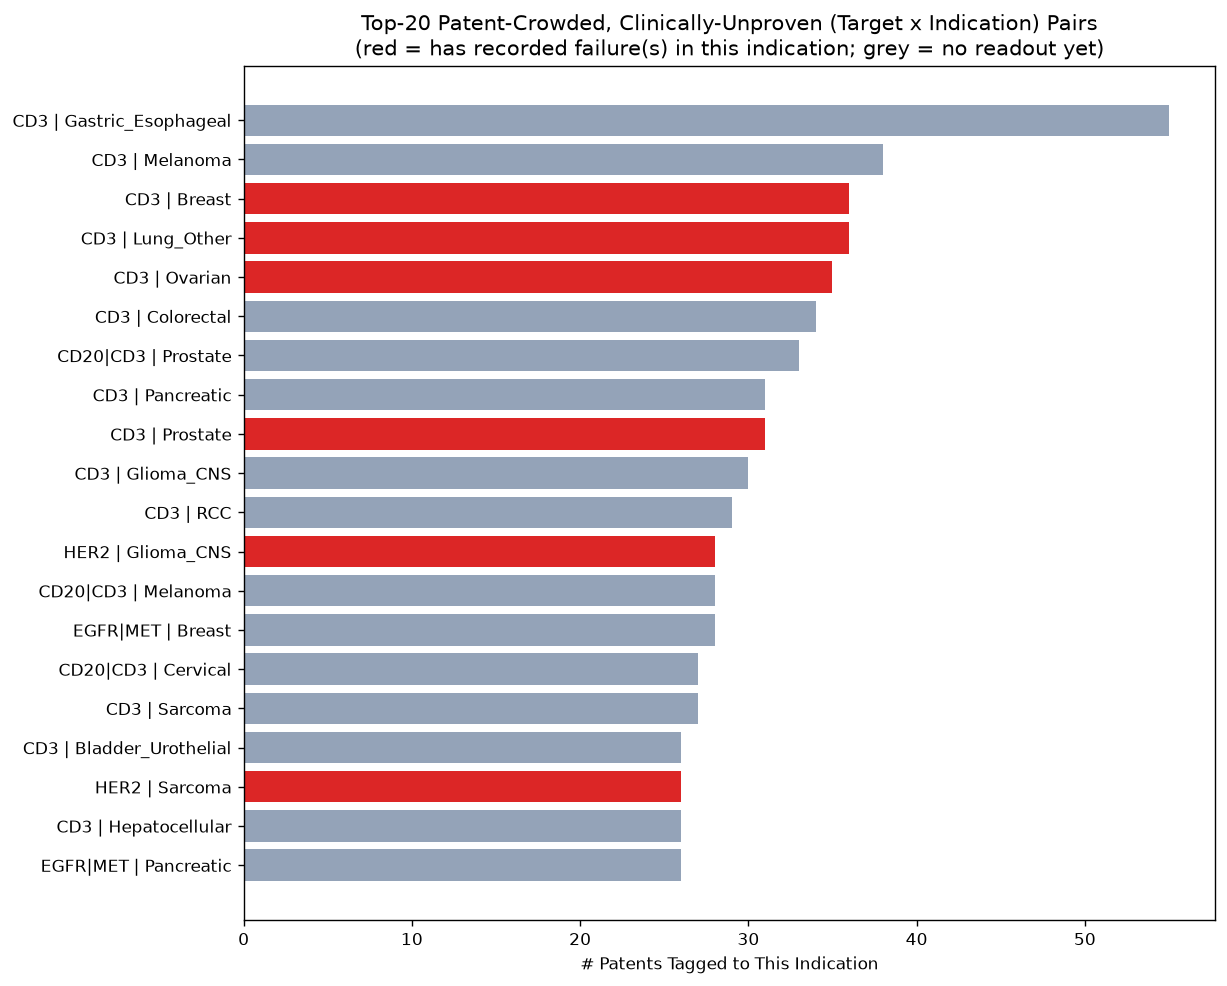

In [20]:
ip_crowded_by_tumor = ip_by_target_tumor[ip_by_target_tumor["n_patents"] >= 5].copy()

cl_unproven_by_tumor = tumor_junction.groupby(["target_h", "tumor_type"]).agg(
    n_trials=("nct", "count"),
    n_success=("outcome_bucket", lambda s: (s == "Success").sum()),
    n_failure=("outcome_bucket", lambda s: (s == "Failure").sum()),
).reset_index()

PATENT_CROWDED_UNPROVEN_BY_TUMOR = ip_crowded_by_tumor.merge(cl_unproven_by_tumor, on=["target_h", "tumor_type"], how="left")
PATENT_CROWDED_UNPROVEN_BY_TUMOR[["n_trials", "n_success", "n_failure"]] = PATENT_CROWDED_UNPROVEN_BY_TUMOR[
    ["n_trials", "n_success", "n_failure"]].fillna(0)
PATENT_CROWDED_UNPROVEN_BY_TUMOR = PATENT_CROWDED_UNPROVEN_BY_TUMOR.rename(columns={"target_h": "target_harmonized"})
PATENT_CROWDED_UNPROVEN_BY_TUMOR = PATENT_CROWDED_UNPROVEN_BY_TUMOR[
    PATENT_CROWDED_UNPROVEN_BY_TUMOR["n_success"] == 0].sort_values("n_patents", ascending=False)
display(PATENT_CROWDED_UNPROVEN_BY_TUMOR, name="entry20_patent_crowded_unproven_by_tumor")
print(f"{len(PATENT_CROWDED_UNPROVEN_BY_TUMOR)} (target, solid-tumor-indication) pairs have >=5 patents tagged "
      f"to that indication but ZERO recorded clinical success in that SAME indication -- the sharpest "
      f"FTO/litigation-exposure view, since a target can look clinically proven overall (Entry 14) while still "
      f"being unproven in a SPECIFIC, heavily patented indication.")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = PATENT_CROWDED_UNPROVEN_BY_TUMOR.head(20).iloc[::-1]
labels = top20["target_harmonized"] + " | " + top20["tumor_type"]
colors_ = ["#dc2626" if f > 0 else "#94a3b8" for f in top20["n_failure"]]
ax.barh(labels, top20["n_patents"], color=colors_)
ax.set_xlabel("# Patents Tagged to This Indication")
ax.set_title("Top-20 Patent-Crowded, Clinically-Unproven (Target x Indication) Pairs\n"
              "(red = has recorded failure(s) in this indication; grey = no readout yet)")
plt.tight_layout()

## Entry 21 [PART C -- TUMOR TYPE DEEP DIVE]: Filing-to-First-Trial Timing Lag, by Solid-Tumor Indication

241 (target, indication) pairs show clinical trials in that SPECIFIC indication starting BEFORE any patent was filed (>=3 patents, possible indication-specific FTO gap):


,target_harmonized,tumor_type,first_filing_year,n_patents,first_trial_year,n_trials,lag_years_filing_to_trial,lead_flag
157,EGFR,Glioma_CNS,2014,12,1985.0,35,-29.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
91,CEACAM5,Lung_Other,2025,5,2000.0,4,-25.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
193,FAP,Colorectal,2021,5,1998.0,2,-23.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
70,CD3,RCC,2015,29,1994.0,2,-21.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
456,PSMA,Prostate,2018,4,2001.0,40,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
65,CD3,Glioma_CNS,2011,30,1994.0,1,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
110,CTLA-4,Ovarian,2019,4,2002.0,9,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
108,CTLA-4,Melanoma,2018,5,2001.0,61,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
507,VEGF,Cervical,2019,4,2002.0,12,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap
107,CTLA-4,Lung_Other,2019,4,2002.0,28,-17.0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap


,lead_flag,n_pairs
0,CLINICAL LEADS (trial started well before first patent) -- possible FTO gap,241
1,IP LEADS (patent filed well before first trial),163
2,Roughly concurrent,111
3,Unknown,6


,target_harmonized,tumor_type,first_trial_year,first_filing_year,lag_years_filing_to_trial,n_trials,n_patents
157,EGFR,Glioma_CNS,1985.0,2014,-29.0,35,12
91,CEACAM5,Lung_Other,2000.0,2025,-25.0,4,5
193,FAP,Colorectal,1998.0,2021,-23.0,2,5
70,CD3,RCC,1994.0,2015,-21.0,2,29
507,VEGF,Cervical,2002.0,2019,-17.0,12,4
65,CD3,Glioma_CNS,1994.0,2011,-17.0,1,30
107,CTLA-4,Lung_Other,2002.0,2019,-17.0,28,4
108,CTLA-4,Melanoma,2001.0,2018,-17.0,61,5
110,CTLA-4,Ovarian,2002.0,2019,-17.0,9,4
456,PSMA,Prostate,2001.0,2018,-17.0,40,4


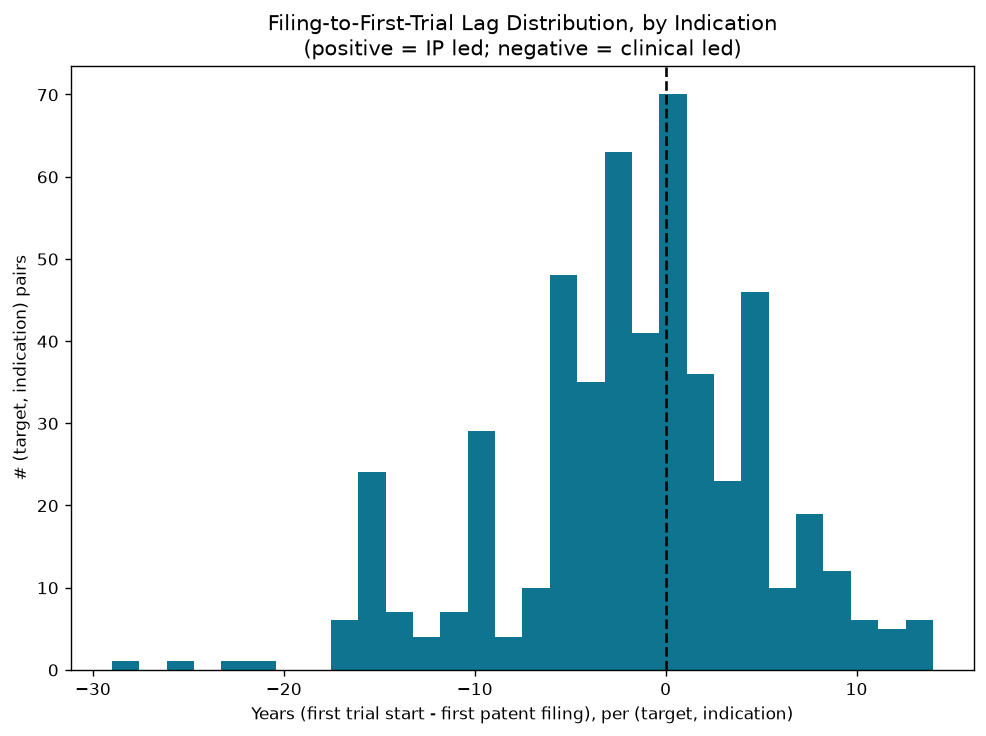

In [21]:
# Entry 12 computed the lead/lag flag per TARGET only. Re-derived here
# per (target, indication) -- a target can be "IP leads" overall while
# clinical trials in ONE specific indication actually started first.
ip_ind_years = con.sql(f'''
    SELECT target_harmonized AS target_h, filing_year,
           TRIM(UNNEST(STR_SPLIT(TRIM(indications), '|'))) AS raw_indication
    FROM read_csv_auto('{IP_CSV}')
    WHERE target_harmonized IS NOT NULL AND indications IS NOT NULL
      AND TRIM(indications) NOT IN ('', 'oncology TA query hit')
''').df()
ip_ind_years["tumor_tags"] = ip_ind_years["raw_indication"].apply(classify_tumor_tags)
ip_ty = ip_ind_years.explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
ip_ty = ip_ty[ip_ty["tumor_type"].notna() & ~ip_ty["tumor_type"].str.startswith("Hematologic")
              & (ip_ty["tumor_type"] != "Solid_Tumor_Basket")]
ip_ty_years = ip_ty.groupby(["target_h", "tumor_type"]).agg(
    first_filing_year=("filing_year", "min"), n_patents=("filing_year", "count")).reset_index()
ip_ty_years = ip_ty_years[ip_ty_years["n_patents"] >= 3]

df_ty = df[["nct", "target_h", "start_year", "tumor_tags"]].explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
df_ty = df_ty[df_ty["tumor_type"].notna()]
cl_ty_years = df_ty.groupby(["target_h", "tumor_type"]).agg(
    first_trial_year=("start_year", "min"), n_trials=("nct", "count")).reset_index()

TIMING_LAG_BY_TUMOR = ip_ty_years.merge(cl_ty_years, on=["target_h", "tumor_type"], how="inner")
TIMING_LAG_BY_TUMOR["lag_years_filing_to_trial"] = TIMING_LAG_BY_TUMOR["first_trial_year"] - TIMING_LAG_BY_TUMOR["first_filing_year"]
TIMING_LAG_BY_TUMOR["lead_flag"] = TIMING_LAG_BY_TUMOR["lag_years_filing_to_trial"].apply(lead_flag)
TIMING_LAG_BY_TUMOR = TIMING_LAG_BY_TUMOR.rename(columns={"target_h": "target_harmonized"})
display(TIMING_LAG_BY_TUMOR.sort_values("lag_years_filing_to_trial"), name="entry21_timing_lag_by_tumor_full")
display(TIMING_LAG_BY_TUMOR["lead_flag"].value_counts().rename_axis("lead_flag").reset_index(name="n_pairs"),
        name="entry21_lead_flag_counts_by_tumor")

clinical_leads_by_tumor = TIMING_LAG_BY_TUMOR[TIMING_LAG_BY_TUMOR["lead_flag"].str.startswith("CLINICAL LEADS")].sort_values(
    "lag_years_filing_to_trial")
print(f"{len(clinical_leads_by_tumor)} (target, indication) pairs show clinical trials in that SPECIFIC indication "
      f"starting BEFORE any patent was filed (>=3 patents, possible indication-specific FTO gap):")
display(clinical_leads_by_tumor[["target_harmonized", "tumor_type", "first_trial_year", "first_filing_year",
                                  "lag_years_filing_to_trial", "n_trials", "n_patents"]],
        name="entry21_clinical_leads_by_tumor")

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(TIMING_LAG_BY_TUMOR["lag_years_filing_to_trial"].dropna(), bins=30, color="#0e7490")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Years (first trial start - first patent filing), per (target, indication)")
ax.set_ylabel("# (target, indication) pairs")
ax.set_title("Filing-to-First-Trial Lag Distribution, by Indication\n(positive = IP led; negative = clinical led)")
plt.tight_layout()

## Entry 22 [PART C -- TUMOR TYPE DEEP DIVE]: CAR-T Clinical Activity vs Antibody-Modality IP Coverage, by Solid-Tumor Indication

556 (target, indication) pairs with CAR-T clinical activity; 412 of them have NO matching antibody-modality IP record for that SAME target+indication combo -- most concentrated in hematologic indications, which is where CAR-T predominantly operates and where this antibody-patent dataset has its thinnest natural coverage.


,target_harmonized,tumor_type,n_cart_trials,n_patents,ip_coverage
111,CD19,Hematologic_Lymphoma,260,0,No antibody-modality IP for this target+indication
110,CD19,Hematologic_Leukemia,217,0,No antibody-modality IP for this target+indication
43,BCMA,Hematologic_Myeloma,108,0,No antibody-modality IP for this target+indication
138,CD19|CD22,Hematologic_Leukemia,51,0,No antibody-modality IP for this target+indication
139,CD19|CD22,Hematologic_Lymphoma,36,0,No antibody-modality IP for this target+indication
127,CD19|CD20,Hematologic_Lymphoma,31,0,No antibody-modality IP for this target+indication
377,GPC3,Hepatocellular,30,11,Antibody-modality IP exists for this target+indication
56,BCMA|CD19,Hematologic_Myeloma,27,0,No antibody-modality IP for this target+indication
192,CD30,Hematologic_Lymphoma,20,0,No antibody-modality IP for this target+indication
83,BCMA|GPRC5D,Hematologic_Myeloma,18,0,No antibody-modality IP for this target+indication


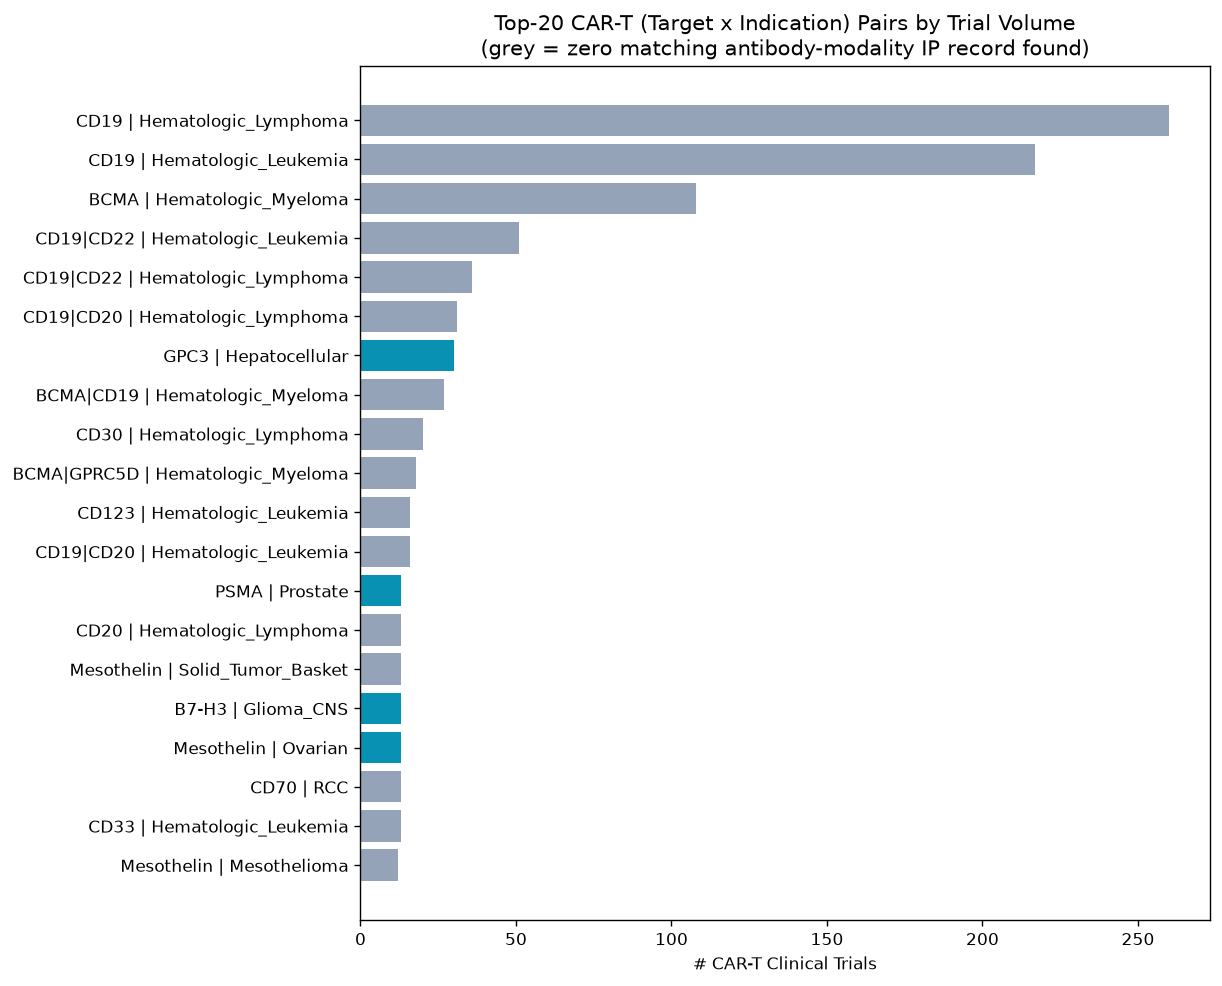

In [22]:
# Entry 15 checked the CAR-T IP blind spot at the target level only, and
# necessarily restricted the IP side to solid-tumor indications (CAR-T's
# real-world indication mix is heavily hematologic, which Entries 9/19/20
# deliberately exclude). Here the IP side is left UNFILTERED by tumor
# category (reusing ip_ind from Entry 9 before its solid-tumor-only
# filter) so hematologic CAR-T indications -- where most CAR-T activity
# actually sits -- are not silently dropped.
cart_df = df[df["modality_code"] == "CAR-T"][["nct", "target_h", "tumor_tags"]]
cart_ty = cart_df.explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
cart_ty = cart_ty[cart_ty["tumor_type"].notna()]
cart_by_tumor = cart_ty.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_cart_trials")

ip_ty_all = ip_ind.explode("tumor_tags").rename(columns={"tumor_tags": "tumor_type"})
ip_ty_all = ip_ty_all[ip_ty_all["tumor_type"].notna()]
ip_ty_all_counts = ip_ty_all.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_patents")

CART_BY_TUMOR = cart_by_tumor.merge(ip_ty_all_counts, on=["target_h", "tumor_type"], how="left")
CART_BY_TUMOR["n_patents"] = CART_BY_TUMOR["n_patents"].fillna(0).astype(int)
CART_BY_TUMOR = CART_BY_TUMOR.rename(columns={"target_h": "target_harmonized"})
CART_BY_TUMOR["ip_coverage"] = np.where(CART_BY_TUMOR["n_patents"] == 0,
                                         "No antibody-modality IP for this target+indication",
                                         "Antibody-modality IP exists for this target+indication")
CART_BY_TUMOR = CART_BY_TUMOR.sort_values("n_cart_trials", ascending=False)
display(CART_BY_TUMOR.head(30), name="entry22_cart_by_tumor")

n_no_ip_pairs = (CART_BY_TUMOR["n_patents"] == 0).sum()
print(f"{len(CART_BY_TUMOR)} (target, indication) pairs with CAR-T clinical activity; {n_no_ip_pairs} of them "
      f"have NO matching antibody-modality IP record for that SAME target+indication combo -- most concentrated "
      f"in hematologic indications, which is where CAR-T predominantly operates and where this antibody-patent "
      f"dataset has its thinnest natural coverage.")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = CART_BY_TUMOR.head(20).iloc[::-1]
labels = top20["target_harmonized"] + " | " + top20["tumor_type"]
colors_ = ["#94a3b8" if p == 0 else "#0891b2" for p in top20["n_patents"]]
ax.barh(labels, top20["n_cart_trials"], color=colors_)
ax.set_xlabel("# CAR-T Clinical Trials")
ax.set_title("Top-20 CAR-T (Target x Indication) Pairs by Trial Volume\n"
              "(grey = zero matching antibody-modality IP record found)")
plt.tight_layout()

## Entry 23: Tumor-Type Analysis -- Executive Summary

In [23]:
n_ft_thin = len(VALIDATED_PATENT_THIN_BY_TUMOR)
n_fto_risk = len(PATENT_CROWDED_UNPROVEN_BY_TUMOR)
n_cl_leads_ty = len(clinical_leads_by_tumor)
n_cart_pairs = len(CART_BY_TUMOR)
n_cart_no_ip_pairs = n_no_ip_pairs

print("TUMOR-TYPE ANALYSIS -- EXECUTIVE SUMMARY (Entries 19-22, Part C)")
print("=" * 88)
print("Entries 10-16 (Part B) were computed at the TARGET level only, pooling every indication "
      "together. This Part C re-cuts the highest-value business questions at the (target, "
      "solid-tumor-indication) level using the shared canonical tumor-type taxonomy from Entry 2/9:")
print()
print(f"  - {n_ft_thin} (target, indication) pairs are clinically validated AND patent-thin in that SAME "
      f"indication -- the sharpest 'file now, this indication' business case (Entry 19).")
print(f"  - {n_fto_risk} (target, indication) pairs are patent-crowded (>=5 patents) with ZERO clinical "
      f"success in that SAME indication -- the sharpest indication-level FTO/litigation exposure (Entry 20).")
print(f"  - {n_cl_leads_ty} (target, indication) pairs show clinical trials starting BEFORE any patent filing "
      f"in that indication -- an indication-specific freedom-to-operate flag finer than Entry 12's target-level view (Entry 21).")
print(f"  - Of {n_cart_pairs} CAR-T (target, indication) pairs, {n_cart_no_ip_pairs} have no matching "
      f"antibody-modality IP coverage at all -- concentrated in hematologic indications, the dataset's "
      f"structural blind spot (Entry 22).")
print()
print("TAKEAWAY: target-level tiers (Part A/B) can mask or overstate an indication-specific opportunity or "
      "risk. Before finalizing a program bet, cross-check the target-level verdict against its indication-level "
      "cut here -- a target that looks 'validated' or 'crowded' overall may be wide open (or still totally "
      "unproven) in the ONE indication actually being considered.")

TUMOR-TYPE ANALYSIS -- EXECUTIVE SUMMARY (Entries 19-22, Part C)
Entries 10-16 (Part B) were computed at the TARGET level only, pooling every indication together. This Part C re-cuts the highest-value business questions at the (target, solid-tumor-indication) level using the shared canonical tumor-type taxonomy from Entry 2/9:

  - 407 (target, indication) pairs are clinically validated AND patent-thin in that SAME indication -- the sharpest 'file now, this indication' business case (Entry 19).
  - 808 (target, indication) pairs are patent-crowded (>=5 patents) with ZERO clinical success in that SAME indication -- the sharpest indication-level FTO/litigation exposure (Entry 20).
  - 241 (target, indication) pairs show clinical trials starting BEFORE any patent filing in that indication -- an indication-specific freedom-to-operate flag finer than Entry 12's target-level view (Entry 21).
  - Of 556 CAR-T (target, indication) pairs, 412 have no matching antibody-modality IP coverage at al